# 📘 Introducción

La asimilación de datos (DA) es una técnica fundamental para mejorar la precisión de modelos numéricos en mecánica de fluidos y dinámica de fluidos computacional (CFD). Esta metodología permite incorporar observaciones experimentales o de sensores dentro de simulaciones numéricas, con el objetivo de corregir desviaciones, mejorar pronósticos y optimizar el uso de recursos computacionales \cite{yang2025strom, chen2024kalman}.

En los últimos años, se han desarrollado enfoques avanzados de asimilación como el Filtro de Kalman (KF), el Filtro de Kalman Ensemble (EnKF), métodos variacionales (4D-Var), así como técnicas híbridas y basadas en aprendizaje profundo, como las *Physics-Informed Neural Networks* (PINNs) \cite{cruz2025vascular} y los *Fourier Neural Operators* (FNO) \cite{xie2025fno}.

Estudios recientes han demostrado el potencial de estos enfoques para abordar problemas con geometrías irregulares, condiciones iniciales complejas y restricciones físicas estrictas \cite{quattromini2024gnn, zhou2024operators}. Además, el desarrollo de plataformas diferenciables y optimizadas por GPU está permitiendo acelerar significativamente las simulaciones CFD tradicionales \cite{fan2025diff}.

Este trabajo se enfoca en comparar distintos métodos de asimilación aplicados a un sistema bidimensional simplificado, evaluando su rendimiento y eficiencia en términos de error cuadrático medio (RMSE) y tiempo de simulación. Se utilizan simulaciones de referencia de alta resolución como “verdad física”, y se exploran múltiples configuraciones experimentales, incluyendo el número y tipo de sensores, frecuencia de observación, y variables involucradas.

La motivación de este análisis proviene de estudios recientes que muestran cómo la integración efectiva de datos observacionales puede mejorar notablemente el desempeño de simulaciones fluidodinámicas, desde aplicaciones biomédicas \cite{cruz2025vascular}, predicción ambiental \cite{bae2025nowcasting}, hasta corrección de túneles de viento en aerodinámica \cite{chen2024kalman}.

---


### 🧠 Modelo Predictivo Base — Simulación de Advección-Difusión 2D

El modelo predictivo utilizado es una simulación numérica de un sistema de mecánica de fluidos simplificado en 2D. Está diseñado para ser lo suficientemente complejo como para representar fenómenos físicos (como transporte de temperatura y presión), pero lo suficientemente eficiente para permitir múltiples ejecuciones rápidas durante la evaluación de métodos de asimilación de datos (DA).

---

#### ⚙️ Dominio Espacial y Condiciones
- **Dimensión espacial**: $x, y \in [0, 1]$
- **Resolución espacial**:
  - Simulación base: $25 \times 25$
  - Verdad física (referencia): $800 \times 800$
- **Condiciones de frontera**: generalmente periódicas o tipo Dirichlet
- **Duración**: número fijo de pasos temporales (e.g. 1000)

---

#### 🔄 Variables Simuladas
- $T(x, y, t)$: Temperatura
- $p(x, y, t)$: Presión
- $\tau(x, y, t)$: Variable auxiliar (e.g. esfuerzo, viscosidad)
- $u(x, y, t), v(x, y, t)$: Componentes de velocidad (flujo 2D)

Cada variable evoluciona en el tiempo siguiendo una dinámica gobernada por ecuaciones de advección-difusión con posible acoplamiento.

---

#### 🧮 Ecuaciones Aproximadas (forma general)

\[
\frac{\partial f}{\partial t} + u \frac{\partial f}{\partial x} + v \frac{\partial f}{\partial y} = \alpha \nabla^2 f + S_f
\]

donde $f \in \{T, p, \tau\}$, $\alpha$ es un coeficiente de difusión, y $S_f$ representa un término fuente (puede ser nulo).

---

#### 💻 Discretización Numérica
- Método de diferencias finitas explícito (implícito en el notebook)
- Discretización temporal: $\Delta t$
- Discretización espacial: $\Delta x = \Delta y = 1/N$ (con $N = 25$ o $800$)
- Salida: historia temporal de todas las variables clave almacenada como archivos `.pkl`

---

#### 🎯 Propósito del Modelo
Este modelo actúa como banco de pruebas para comparar el rendimiento de distintos métodos de asimilación de datos, evaluando:

- Precisión: mediante error cuadrático medio (RMSE)
- Eficiencia computacional: tiempo de asimilación

Se experimenta variando:
- Número y tipo de sensores
- Variables observadas
- Frecuencia de observación
º

### 🔍 Métodos de Asimilación de Datos (DA)

En este trabajo se implementan y comparan varios enfoques clásicos de Asimilación de Datos, que permiten combinar información observada (parcial y ruidosa) con simulaciones numéricas para mejorar su precisión.

---

#### 🌀 1. **Nudging**
- También conocido como “relaxation to observations”.
- Se basa en añadir un término corrector proporcional a la diferencia entre el modelo y las observaciones:
\[
\frac{\partial f}{\partial t} = \text{modelo} + \gamma (f_\text{obs} - f)
\]
- Ventajas:
  - Fácil de implementar
  - Bajo coste computacional
- Limitaciones:
  - No óptimo estadísticamente
  - Puede sobreajustar si $\gamma$ es muy grande

---

#### 🔁 2. **Kalman Filter (KF)**
- Método lineal y recursivo, óptimo bajo ruido Gaussiano.
- Actualiza el estado del sistema usando su covarianza:
\[
\mathbf{x}_k = \mathbf{x}_k^- + \mathbf{K}_k(\mathbf{y}_k - \mathbf{H} \mathbf{x}_k^-)
\]
donde $\mathbf{K}_k$ es la ganancia de Kalman.
- Pros:
  - Óptimo en entornos lineales
  - Considera incertidumbre
- Contras:
  - Requiere almacenar matrices grandes
  - No escalable para grandes sistemas

---

#### 🌪️ 3. **Ensemble Kalman Filter (EnKF)**
- Variante estocástica del KF que usa un conjunto de simulaciones (“ensemble”) para representar la estadística:
\[
\mathbf{x}_k^i = \mathbf{x}_k^{i-} + \mathbf{K}_k(\mathbf{y}_k^i - \mathbf{H} \mathbf{x}_k^{i-})
\]
- Beneficios:
  - Apto para sistemas no lineales
  - Requiere menos almacenamiento
- Inconvenientes:
  - Introduce errores de muestreo
  - Requiere buen diseño del ensemble

---

#### ⏳ 4. **4D-Var (Four-Dimensional Variational)**
- Método basado en optimización: encuentra el estado inicial que minimiza la diferencia entre el modelo y las observaciones a lo largo del tiempo:
\[
J(\mathbf{x}_0) = \sum_t \| \mathbf{y}_t - \mathbf{H} \mathbf{x}_t \|^2 + \text{regularización}
\]
- Ventajas:
  - Alta precisión
  - Usa toda la ventana temporal
- Desventajas:
  - Requiere cálculo del adjunto
  - Costoso en tiempo y memoria

---

### ⚖️ Comparativa

| Método  | Lineal | Usa estadística | Escalable | Coste |
|---------|--------|------------------|------------|--------|
| Nudging | ✖      | ✖                | ✅         | 🟢 Bajo |
| KF      | ✅      | ✅                | ✖          | 🔴 Alto |
| EnKF    | ✖      | ✅ (ensemble)     | ✅         | 🟡 Medio |
| 4D-Var  | ✖      | ✅ (implícita)    | ⚠️         | 🔴 Alto |

---

Estos métodos son aplicados sobre distintas configuraciones del sistema: variables observadas ($T$, $p$, $\tau$), frecuencia de observación, y número de sensores.


### 📊 Escalabilidad de Métodos de Asimilación de Datos

| Método              | ¿Escalable? | Explicación                                                                                          |
|---------------------|-------------|------------------------------------------------------------------------------------------------------|
| **Kalman Filter (KF)**    | ❌ No      | Requiere manejar matrices de covarianza completas de tamaño $N \times N$, lo cual es ineficiente en modelos grandes. |
| **Ensemble Kalman Filter (EnKF)** | ✅ Sí     | Utiliza un conjunto de simulaciones (ensembles) para estimar la estadística, evitando cálculos masivos.     |
| **Nudging**              | ✅ Sí     | Método sencillo y puntual; no requiere matrices ni cálculos costosos. Ideal para grandes dominios.        |
| **4D-Var**               | ⚠️ Depende | Aunque preciso, implica resolver un problema de optimización con el modelo adjunto. Costoso en modelos complejos. |


### 🧪 Implementación de los Métodos de Asimilación de Datos

Los métodos de DA se aplican sobre un modelo numérico base de baja resolución ($25 \times 25$), con referencia en alta resolución ($800 \times 800$), usando distintas configuraciones de sensores, observaciones y frecuencias.

---

#### 🧷 Observaciones simuladas
- Extraídas desde la “verdad física” (simulación de alta resolución interpolada).
- Variables observadas: $T$, $p$, $\tau$, individualmente o combinadas.
- Sensores distribuidos aleatoriamente sobre la malla 25×25.
- Frecuencias de observación: cada 70, 150 o 300 pasos de tiempo.

---

#### 🛠️ Implementación general
Para cada método (nudging, KF, EnKF, 4D-Var), se realiza:

1. **Carga de configuración experimental** (sensores, frecuencia, variables).
2. **Interpolación de observaciones** desde la referencia a las ubicaciones de sensores.
3. **Aplicación del método de DA**, modificando el campo simulado a medida que se avanza en el tiempo.
4. **Almacenamiento** de las simulaciones resultantes como `.pkl`, incluyendo historia temporal de:
   - Variables físicas: $T$, $p$, $\tau$, $u$, $v$
   - Malla espacial: $X_\text{star}$, $Y_\text{star}$
   - Tiempo de asimilación y parámetros usados

---

#### 🧮 Ejecución masiva
- Cada combinación de parámetros (método, sensores, frecuencia, variables) genera una simulación distinta.
- Estas simulaciones se organizan bajo la carpeta `DA/25x25/` con nombres codificados según la configuración.
- Posteriormente se evalúan de forma automatizada.

---


### 📊 Análisis y Evaluación de Resultados

Una vez realizadas todas las simulaciones con los distintos métodos de Asimilación de Datos (DA), se realiza un análisis cuantitativo y comparativo para evaluar su efectividad.

---

#### 🔁 Interpolación de la referencia
- La “verdad física” (simulación de alta resolución de $800 \times 800$) es interpolada a la malla $25 \times 25$ usando `RegularGridInterpolator`.
- Esto permite comparar todas las simulaciones en la misma resolución.

---

#### ⚖️ Normalización de variables
- Las variables principales ($T$ y $p$) se normalizan globalmente:
\[
f_\text{norm} = \frac{f - \min(f)}{\max(f) - \min(f)}
\]
- Evita que una variable domine el análisis por tener mayor magnitud.
- Se aplica sobre todos los frames de una variable.

---

#### 📐 Cálculo de error (RMSE)
- Se utiliza el **Error Cuadrático Medio** para medir precisión respecto a la referencia:
\[
\text{RMSE} = \sqrt{ \frac{1}{N} \sum_{i=1}^{N} \left(f_i^\text{sim} - f_i^\text{ref}\right)^2 }
\]
- Se calcula por variable ($T$, $p$), por frame, y luego se promedia.
- El criterio de precisión es:
  \[
  \text{RMSE promedio} = \frac{\text{RMSE}_T + \text{RMSE}_p}{2}
  \]

---

#### 🕒 Evaluación de eficiencia
- Se registra el tiempo total de ejecución de cada método (`asimilacion_time`).
- Se comparan todos los métodos según:
  - **Precisión**: simulación con menor RMSE promedio
  - **Eficiencia**: simulación con menor tiempo de asimilación

---

#### 📊 Visualización de resultados
- Se organizan los resultados en un `DataFrame` para comparación tabular.
- Se pueden generar:
  - Animaciones por variable y método
  - Mapas de calor (heatmaps)
  - Gráficas comparativas RMSE vs. sensores/frecuencia

---

#### 🏁 Resultado final
El análisis permite identificar combinaciones óptimas de:
- Método de DA
- Variables observadas
- Número y distribución de sensores
- Frecuencia de observación

...para lograr el mejor equilibrio entre precisión y coste computacional.


# 🧭 Proceso de Análisis de Asimilación de Datos

Este flujo resume todas las etapas clave, desde la generación de simulaciones hasta la evaluación cuantitativa de sus resultados.

---

## 🔹 1. Simulación base (sin asimilación)
- Se realiza una simulación de referencia en malla **25×25** sin aplicar ningún método de asimilación.
- Esta simulación sirve como **comparación base**.

---

## 🔹 2. Simulación de alta resolución (referencia “real”)
- Simulación en malla **800×800**, considerada como la “verdad física”.
- Sirve como **referencia para evaluar el error (RMSE)** de las simulaciones con asimilación.

---

## 🔹 3. Asimilación de datos

Se ejecutan múltiples simulaciones aplicando distintos métodos:

### Métodos:
- `nudging`
- `kf` (Kalman Filter)
- `enkf` (Ensemble Kalman Filter)
- `4dvar` (4D-Var)

### Configuraciones:
- **Variables observadas**: `T`, `p`, `tau`, `T,p`, `T,tau`, `T,p,tau`
- **Número de sensores**: 5, 10, 20
- **Frecuencia de observación**: cada 70, 150 o 300 pasos

Cada simulación se guarda como `.pkl` en `DA/25x25/`, codificando su configuración en el nombre.

---

## 🔹 4. Contenido de archivos `.pkl` de simulación

Cada archivo contiene:
- `"T_history"`, `"p_history"`, `"tau_history"`: historia temporal por variable
- `"u_history"`, `"v_history"`: velocidades
- `"X_star"`, `"Y_star"`: malla espacial
- `"params"`: parámetros de configuración
- `"asimilacion_time"`: tiempo total de asimilación

---

## 🔹 5. Interpolación de la referencia (800×800 → 25×25)

Se interpolan las variables de la referencia de alta resolución para compararlas en la misma malla 25×25 que las simulaciones asimiladas.

Se usa `scipy.interpolate.RegularGridInterpolator`.

---

## 🔹 6. Normalización de datos

Se normalizan las variables `T` y `p` para evitar diferencias de escala:

### Normalización global:
\[
f_\text{norm} = \frac{f - \min(f)}{\max(f) - \min(f)}
\]

- Aplicada sobre **todos los frames** de una variable
- Asegura que todas las comparaciones estén en rango `[0, 1]`

---

## 🔹 7. Cálculo de error (RMSE)

Se usa el Error Cuadrático Medio para medir la diferencia respecto a la referencia:

\[
\text{RMSE} = \sqrt{ \frac{1}{N} \sum_{i=1}^{N} (f_i^\text{sim} - f_i^\text{ref})^2 }
\]

- Calculado por frame y luego promediado
- Se evalúan principalmente `T` y `p`

---

## 🔹 8. Evaluación de resultados

Se identifica:

### 🏆 La simulación **más precisa** por método:
- La que minimiza `(RMSE_T + RMSE_p) / 2`

### ⚡ La simulación **más eficiente** por método:
- La que minimiza `asimilacion_time`

Se almacenan los resultados en un `DataFrame` para inspección y visualización.

---

## 🔹 9. Visualización (opcional)

- Se pueden generar animaciones por variable (`T`, `p`, `u`, `v`, `tau`, etc.)
- Las mejores simulaciones se pueden visualizar en comparación con la referencia

---

## ✅ Resultado final

Este análisis permite evaluar cómo afectan:
- El método de asimilación
- Las variables observadas
- El número de sensores
- La frecuencia de observación

...al **rendimiento y precisión** de las simulaciones.



---
---
## 🔁 Simulación en múltiples resoluciones

Se simulan los campos para distintas resoluciones (`25x25` hasta `800x800`). Los resultados se guardan en `sim_dif_resl/{res}.pkl`.


In [2]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from numba import njit, prange
from matplotlib.animation import FuncAnimation,FFMpegWriter, PillowWriter
from IPython.display import HTML
from scipy.interpolate import RegularGridInterpolator
import time
import pandas as pd
from copy import deepcopy
import seaborn as sns
from numba import set_num_threads
from itertools import product
from tqdm import tqdm
from collections import defaultdict
import copy


set_num_threads(14)  # Reemplaza N con el número de núcleos que quieres usar

# Funcion general de simulacion

In [37]:
@njit(parallel=True, fastmath=True)
def actualizar_campos(presion_adversa, u_old, v_old, p_old, T_old, u_star, v_star, p_star, T_star,
                      Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny):
    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_u_x = u_old[i, j] * (u_old[i, j + 1] - u_old[i, j - 1]) / (2 * dx_star)
            conv_u_y = v_old[i, j] * (u_old[i + 1, j] - u_old[i - 1, j]) / (2 * dy_star)
            diff_u_x = (u_old[i, j + 1] - 2 * u_old[i, j] + u_old[i, j - 1]) / dx_star**2
            diff_u_y = (u_old[i + 1, j] - 2 * u_old[i, j] + u_old[i - 1, j]) / dy_star**2
            u_star[i, j] += dt_star * (-conv_u_x - conv_u_y + (1 / Re) * (diff_u_x + diff_u_y))

            conv_v_x = u_old[i, j] * (v_old[i, j + 1] - v_old[i, j - 1]) / (2 * dx_star)
            conv_v_y = v_old[i, j] * (v_old[i + 1, j] - v_old[i - 1, j]) / (2 * dy_star)
            diff_v_x = (v_old[i, j + 1] - 2 * v_old[i, j] + v_old[i, j - 1]) / dx_star**2
            diff_v_y = (v_old[i + 1, j] - 2 * v_old[i, j] + v_old[i - 1, j]) / dy_star**2
            grad_p_y = (p_old[i + 1, j] - p_old[i - 1, j]) / (2 * dy_star)
            v_star[i, j] += dt_star * (-conv_v_x - conv_v_y - Eu * grad_p_y + (1 / Re) * (diff_v_x + diff_v_y))

    for _ in range(20):
        for i in prange(1, ny - 1):
            for j in prange(1, nx - 1):
                div = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star) + \
                      (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
                p_star[i, j] = 0.25 * (p_old[i + 1, j] + p_old[i - 1, j] +
                                       p_old[i, j + 1] + p_old[i, j - 1] -
                                       (dx_star * dy_star) / (2 * (dx_star**2 + dy_star**2)) * div)
    
    # Gradiente de presión controlado
    for j in prange(nx):
        x = j * dx_star
        for i in prange(ny):
            if x <= 0.3:
                p_star[i, j] += 0.01  # presión constante en entrada
            else:
                p_star[i, j] += presion_adversa * (x - 0.3)


    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            u_star[i, j] -= dt_star * Eu * (p_star[i, j + 1] - p_star[i, j - 1]) / (2 * dx_star)
            v_star[i, j] -= dt_star * Eu * (p_star[i + 1, j] - p_star[i - 1, j]) / (2 * dy_star)

    for i in prange(1, ny - 1):
        for j in prange(1, nx - 1):
            conv_T_x = u_star[i, j] * (T_old[i, j + 1] - T_old[i, j - 1]) / (2 * dx_star)
            conv_T_y = v_star[i, j] * (T_old[i + 1, j] - T_old[i - 1, j]) / (2 * dy_star)
            diff_T_x = (T_old[i, j + 1] - 2 * T_old[i, j] + T_old[i, j - 1]) / dx_star**2
            diff_T_y = (T_old[i + 1, j] - 2 * T_old[i, j] + T_old[i - 1, j]) / dy_star**2
            Sxx = (u_star[i, j + 1] - u_star[i, j - 1]) / (2 * dx_star)
            Syy = (v_star[i + 1, j] - v_star[i - 1, j]) / (2 * dy_star)
            Sxy = 0.5 * ((u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star) +
                         (v_star[i, j + 1] - v_star[i, j - 1]) / (2 * dx_star))
            viscous_heating = (Ec / Re) * (2 * (Sxx**2 + Syy**2) + 4 * Sxy**2)
            T_star[i, j] += dt_star * (-conv_T_x - conv_T_y +
                                       (1 / (Re * Pr)) * (diff_T_x + diff_T_y) +
                                       viscous_heating)

    tau = np.zeros((ny, nx))
    for i in prange(1, ny - 1):
        for j in prange(nx):
            tau[i, j] = (u_star[i + 1, j] - u_star[i - 1, j]) / (2 * dy_star)

# Condiciones de frontera
    v_star[0, :] = 0
    v_star[-1, :] = 0
    u_star[0, :] = -0.5
    u_star[-1, :] = 1.0
    u_star[:, -1] = u_star[:, -2]
    p_star[:, 0] = p_star[:, 1]
    p_star[:, -1] = p_star[:, -2]
    p_star[0, :] = p_star[1, :]
    p_star[-1, :] = p_star[-2, :]

    return u_star, v_star, p_star, T_star, tau

def run_simulacion_general(nx=25, ny=25, presion_adversa=0.3,
                           observaciones_dict=None,
                           metodo_asimilacion=None,
                           variables_asimilar=['T'],
                           metodo_kwargs={},
                           N_FRAMES=300):
    """
    Simulación general que permite asimilación de datos opcional (sin guardado en disco).

    Parámetros:
    -----------
    nx, ny : int
        Resolución espacial.
    presion_adversa : float
        Presión aplicada en la entrada.
    observaciones_dict : dict
        Diccionario {timestep: observaciones}.
    metodo_asimilacion : function or None
        Función que aplica asimilación (e.g., aplicar_nudging).
    variables_asimilar : list of str
        Variables a asimilar (e.g., ['T', 'p']).
    metodo_kwargs : dict
        Parámetros adicionales para el método de asimilación.
    N_FRAMES : int
        Número de frames a guardar (espaciados uniformemente).

    Retorna:
    --------
    dict con históricos y parámetros.
    """

    # --- Parámetros físicos y temporales ---
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    save_interval = max(1, nt // N_FRAMES)
    save_times = set(range(0, nt, save_interval))
    save_times.add(nt - 1)

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # --- Condiciones iniciales ---
    u0, up = 1.0, -0.5
    T0_star, T1_star = 0.0, 0.0
    u_star = np.ones((ny, nx)) * u0
    v_star = np.zeros((ny, nx))
    p_star = np.zeros((ny, nx))
    T_star = np.ones((ny, nx)) * T1_star
    u_star[0, :] = up
    u_star[-1, :] = u0
    T_star[0, :] = T0_star
    T_star[-1, :] = T1_star

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_assim_time = 0.0

    for n in range(nt):
        u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
        u_star, v_star, p_star, T_star, tau = actualizar_campos(
            presion_adversa, u_old, v_old, p_old, T_old,
            u_star, v_star, p_star, T_star,
            Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
        )

        # Asimilación si corresponde
        if observaciones_dict and n in observaciones_dict and metodo_asimilacion:
            t0 = time.time()
            obs_t = observaciones_dict[n]
            for var in variables_asimilar:
                if var in obs_t:
                    campo = {'T': T_star, 'p': p_star, 'tau': tau}[var]
                    campo_asim = metodo_asimilacion(
                        campo_modelo=campo,
                        observaciones=obs_t,
                        variable=var,
                        nx=nx, ny=ny,
                        **metodo_kwargs
                    )
                    if var == 'T': T_star = campo_asim
                    elif var == 'p': p_star = campo_asim
                    elif var == 'tau': tau = campo_asim
            total_assim_time += time.time() - t0

        # Guardar en memoria
        if n in save_times:
            u_hist.append(u_star.copy())
            v_hist.append(v_star.copy())
            p_hist.append(p_star.copy())
            T_hist.append(T_star.copy())
            tau_hist.append(tau.copy())

    print("\n✅ Simulación finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "metodo_asimilacion": metodo_asimilacion.__name__ if metodo_asimilacion else None,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_assim_time
    }



In [38]:
EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:

    # --- Asegura que existe la carpeta de salida ---
    os.makedirs("sim_dif_resl", exist_ok=True)

    # --- Lista de resoluciones (lado x = lado y) ---
    resoluciones = [25, 50, 100, 200, 400, 800]

    # --- Simulación para cada resolución ---
    for res in tqdm(resoluciones, desc="Generando simulaciones"):
        print(f"\n🔧 Resolución: {res}x{res}")

        sim_data = run_simulacion_general(
            nx=res, ny=res,
            metodo_asimilacion=None,
            N_FRAMES=300,
            presion_adversa=0.3
        )

        ruta_salida = f"sim_dif_resl/{res}.pkl"
        with open(ruta_salida, "wb") as f:
            pickle.dump(sim_data, f)

        print(f"✅ Guardado: {ruta_salida}")



## 📈 Estudio de Convergencia

In [10]:
def calcular_parametros(sim_data):
    """
    Calcula parámetros de separación, burbuja de recirculación y grosor de  capa límite
    a partir de los datos de simulación.
    Parámetros:
    - sim_data: diccionario con datos de simulación que contiene:
        - 'u_history': historial de velocidades (array 2D)
        - 'X_star': coordenadas X (array 2D)
        - 'Y_star': coordenadas Y (array 2D)
    Retorna:
    - x_sep: posición de separación (float)
    - bubble: tamaño de la burbuja de recirculación (float)
    - delta: grosor de la capa límite (float)
    """
    u_hist = sim_data['u_history']
    X = sim_data['X_star']
    Y = sim_data['Y_star']

    final_u = u_hist[-1]

    # Tomamos la línea más baja (y≈0)
    y_line_idx = 1  # la segunda fila desde abajo
    u_bottom = final_u[y_line_idx, :]
    x_vals = X[y_line_idx, :]

    # Buscar cambio de signo de positivo a negativo (indica separación)
    signo = np.sign(u_bottom)
    cambios = np.where(np.diff(signo) < 0)[0]

    x_sep = None
    if len(cambios) > 0:
        x_sep = x_vals[cambios[0]]
    
    # Buscar burbuja de recirculación (donde u < 0)
    indices_negativos = np.where(u_bottom < 0)[0]
    bubble = None
    if len(indices_negativos) > 1:
        bubble = x_vals[indices_negativos[-1]] - x_vals[indices_negativos[0]]

    # Calcular delta como grosor de la capa límite al final
    y_vals = Y[:, -1]  # columna más a la derecha
    u_profile = final_u[:, -1]
    u_inf = np.max(u_profile)
    delta = None
    for i in range(len(u_profile)):
        if u_profile[i] >= 0.99 * u_inf:
            delta = y_vals[i]
            break

    return x_sep, bubble, delta



In [13]:
# Asegúrate de que calcular_parametros está definida antes de este bloque

# --- Configuración ---
carpeta = 'sim_dif_res'
resoluciones = [25, 50, 100, 200, 400, 800]

# --- Resultados del análisis ---
resultados = []

def cargar_datos(resolucion):
    nombre_archivo = os.path.join(carpeta, f"{resolucion}.pkl")
    with open(nombre_archivo, 'rb') as f:
        data = pickle.load(f)
    return data

# --- Carga y análisis de datos ---
for res in resoluciones:
    try:
        datos = cargar_datos(res)
        x_sep, bubble, delta = calcular_parametros(datos)
        resultados.append({
            'resolucion': res,
            'x_sep': x_sep,
            'bubble_size': bubble,
            'delta': delta
        })
    except Exception as e:
        print(f"❌ Error al procesar resolución {res}: {e}")

# --- Mostrar resultados individuales ---
for r in resultados:
    print(f"{r['resolucion']}x{r['resolucion']} -> "
          f"x_sep: {r['x_sep']}, bubble: {r['bubble_size']}, delta: {r['delta']}")

# --- Variables para análisis de convergencia ---
resoluciones_validas = [r['resolucion'] for r in resultados if r['delta'] is not None]
x_sep_vals = [r['x_sep'] for r in resultados if r['x_sep'] is not None]
bubble_vals = [r['bubble_size'] for r in resultados if r['bubble_size'] is not None]
delta_vals = [r['delta'] for r in resultados if r['delta'] is not None]


25x25 -> x_sep: 0.125, bubble: 0.8333333333333334, delta: 1.0
50x50 -> x_sep: 0.061224489795918366, bubble: 0.9183673469387755, delta: 1.0
100x100 -> x_sep: 0.04040404040404041, bubble: 0.9494949494949495, delta: 1.0
200x200 -> x_sep: 0.020100502512562814, bubble: 0.9748743718592965, delta: 1.0
400x400 -> x_sep: 0.010025062656641603, bubble: 0.987468671679198, delta: 1.0
800x800 -> x_sep: 0.0050062578222778474, bubble: 0.9937421777221527, delta: 1.0


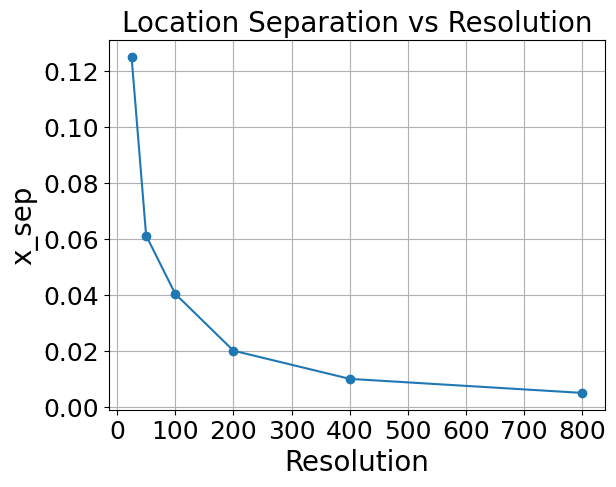

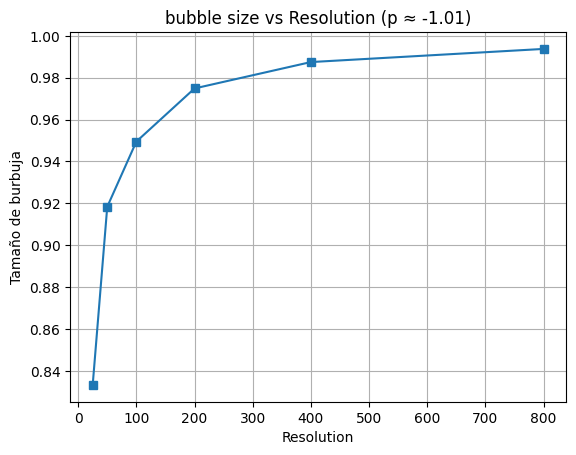

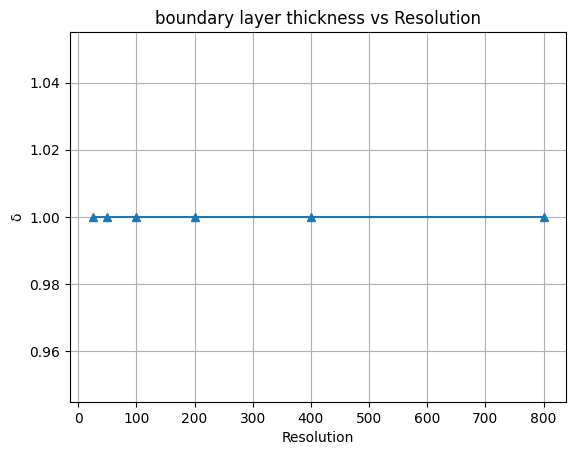

In [17]:
# Datos obtenidos
resoluciones = [25, 50, 100, 200, 400, 800]

# Función para calcular orden de convergencia
def orden_convergencia(f1, f2, f3, r):
    return np.log((f3 - f2) / (f2 - f1)) / np.log(r)

# Calcular orden de convergencia (solo con los 3 valores más refinados)
r = 2
p_xsep = orden_convergencia(x_sep_vals[2], x_sep_vals[3], x_sep_vals[4], r)
p_bubble = orden_convergencia(bubble_vals[2], bubble_vals[3], bubble_vals[4], r)

# delta es casi constante; su orden no es confiable
delta_casi_constante = all(np.isclose(d, 1.0) for d in delta_vals[:-1])
p_delta = None if delta_casi_constante else orden_convergencia(delta_vals[2], delta_vals[3], delta_vals[4], r)

# Gráfica para x_sep
plt.figure()
plt.plot(resoluciones, x_sep_vals, marker='o')
plt.title(f'Location Separation vs Resolution', fontsize=20)
plt.xlabel('Resolution', fontsize=20)
plt.ylabel('x_sep', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid()

# Gráfica para tamaño de burbuja
plt.figure()
plt.plot(resoluciones, bubble_vals, marker='s')
plt.title(f'bubble size vs Resolution (p ≈ {p_bubble:.2f})')
plt.xlabel('Resolution')
plt.ylabel('Tamaño de burbuja')
plt.grid()

# Gráfica para delta
plt.figure()
plt.plot(resoluciones, delta_vals, marker='^')
title = 'boundary layer thickness vs Resolution'
if p_delta is not None:
    title += f' (p ≈ {p_delta:.2f})'
plt.title(title)
plt.xlabel('Resolution')
plt.ylabel('δ')
plt.grid()

plt.show()


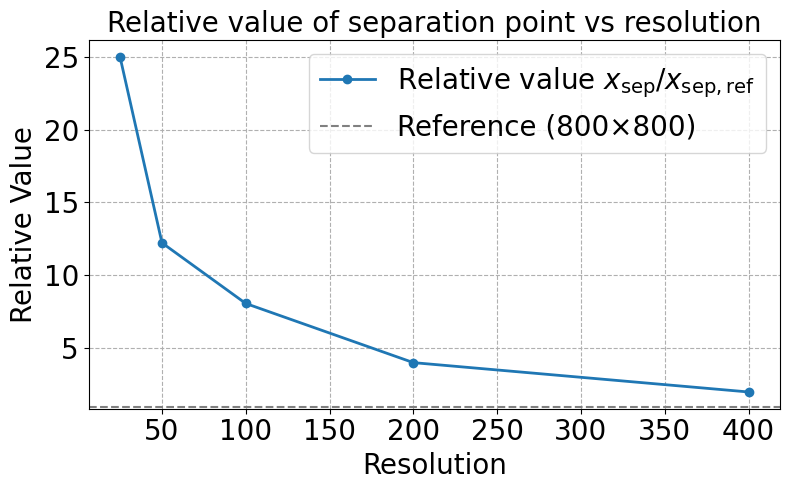

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --- Valores de entrada ---
resoluciones = [25, 50, 100, 200, 400, 800]  # Resoluciones simuladas

# --- Valores de x_sep previamente calculados ---
# Asegúrate de que x_sep_vals esté definido antes de este bloque
# Por ejemplo:
# x_sep_vals = [0.32, 0.34, 0.36, 0.37, 0.375, 0.376]

# --- Valor de referencia (mayor resolución) ---
x_sep_ref = x_sep_vals[-1]

# --- Cálculo del valor relativo respecto al de referencia ---
x_sep_relativo = [val / x_sep_ref for val in x_sep_vals[:-1]]  # excluye el último (800x800)

# --- Gráfica ---
plt.figure(figsize=(8, 5))
plt.plot(resoluciones[:-1], x_sep_relativo, marker='o', linewidth=2, label=r'Relative value $x_{\mathrm{sep}} / x_{\mathrm{sep,ref}}$')
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1.5, label='Reference (800×800)')
plt.title("Relative value of separation point vs resolution", fontsize=20)
plt.xlabel("Resolution", fontsize=20)
plt.ylabel("Relative Value", fontsize=20)
plt.grid(True, which="both", ls="--")
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()


# Normalizacion de los datos

In [42]:
def normalizar_simulaciones(carpeta_entrada="sim_dif_res", carpeta_salida="sim_normal"):
    os.makedirs(carpeta_salida, exist_ok=True)

    # --- 1. Buscar archivos .pkl ---
    archivos = [f for f in os.listdir(carpeta_entrada) if f.endswith(".pkl")]
    if not archivos:
        print("❌ No se encontraron archivos .pkl en la carpeta de entrada.")
        return

    print(f"🔍 Archivos encontrados: {archivos}")

    # --- 2. Extraer valores globales ---
    all_vals = {"T": [], "p": [], "tau": []}
    sims = {}

    for archivo in archivos:
        with open(os.path.join(carpeta_entrada, archivo), "rb") as f:
            sim = pickle.load(f)
            sims[archivo] = sim

            for var in ["T", "p", "tau"]:
                hist = sim.get(f"{var}_history", [])
                for frame in hist:
                    all_vals[var].extend(frame.ravel())

    # --- 3. Calcular el valor absoluto máximo global ---
    norm_info = {}
    for var in ["T", "p", "tau"]:
        arr = np.array(all_vals[var])
        max_abs = np.max(np.abs(arr))
        if max_abs == 0:
            print(f"⚠️ {var}: Todos los valores son cero. Se omite normalización.")
            norm_info[var] = None
        else:
            norm_info[var] = max_abs
            print(f"🔧 Normalización {var}: max |valor| = {max_abs:.6f}")

    # --- 4. Aplicar normalización y guardar ---
    for archivo, sim in sims.items():
        sim_norm = copy.deepcopy(sim)
        for var in ["T", "p", "tau"]:
            if norm_info[var] is not None:
                max_abs = norm_info[var]
                sim_norm[f"{var}_history"] = [
                    f / max_abs for f in sim[f"{var}_history"]
                ]
        salida_path = os.path.join(carpeta_salida, archivo)
        with open(salida_path, "wb") as f:
            pickle.dump(sim_norm, f)
        print(f"✅ Guardado normalizado: {salida_path}")

    print("🎯 Todas las simulaciones fueron normalizadas y guardadas (preservando signo).")


In [43]:
EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:
    # Ejecutar la normalización global sobre los datos en sim_dif_res
    normalizar_simulaciones(
        carpeta_entrada="sim_dif_res",
        carpeta_salida="sim_normal"
    )

In [44]:
def animate_results(sim_data):
    X_star = sim_data["X_star"]
    Y_star = sim_data["Y_star"]
    u_hist = sim_data["u_history"]
    v_hist = sim_data["v_history"]
    p_hist = sim_data["p_history"]
    T_hist = sim_data["T_history"]
    tau_hist = sim_data["tau_history"]
    resolution = X_star.shape[1]
    adverse_pressure = sim_data["params"].get("presion_adversa", "N/A")

    fig, axs_grid = plt.subplots(2, 2, figsize=(10, 8))
    axs = axs_grid.flatten()

    titles = ['Velocity Magnitude |u*|', 'Temperature T*', 'Pressure p*', 'Shear Stress τ*']
    cmaps = ['jet', 'jet', 'viridis', 'coolwarm']

    datasets = [
        np.sqrt(u_hist[0]**2 + v_hist[0]**2),
        T_hist[0], p_hist[0], tau_hist[0]
    ]

    for ax, title, cmap, data in zip(axs, titles, cmaps, datasets):
        cf = ax.contourf(X_star, Y_star, data, levels=20, cmap=cmap)
        ax.set_title(title, fontsize=20)
        ax.set_xlabel("x*", fontsize=20)
        ax.set_ylabel("y*", fontsize=20)
        plt.colorbar(cf, ax=ax).ax.tick_params(labelsize=10)

    fig.suptitle(
        f"Resolution {resolution}x{resolution} | Adverse Pressure = {adverse_pressure} | t* = 0.00",
        fontsize=20
    )
    plt.tight_layout()

    def update(frame):
        t_star = frame / (len(u_hist) - 1)
        updated_data = [
            np.sqrt(u_hist[frame]**2 + v_hist[frame]**2),
            T_hist[frame],
            p_hist[frame],
            tau_hist[frame]
        ]
        for ax, data, cmap in zip(axs, updated_data, cmaps):
            for coll in list(ax.collections):
                coll.remove()
            ax.contourf(X_star, Y_star, data, levels=20, cmap=cmap)
        fig.suptitle(
            f"Resolution {resolution}x{resolution} | Adverse Pressure = {adverse_pressure} | t* = {t_star:.2f}",
            fontsize=20
        )
        return axs

    anim = FuncAnimation(fig, update, frames=len(u_hist), interval=100, blit=False)
    return anim


In [45]:
EJECUTAR_SIMULACIONES = False  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:

    # === Ejecutar para todos los archivos normalizados ===
    input_dir = "sim_normal"
    output_dir = "anim_normal"
    os.makedirs(output_dir, exist_ok=True)

    for archivo in os.listdir(input_dir):
        if not archivo.endswith(".pkl"):
            continue

        with open(os.path.join(input_dir, archivo), "rb") as f:
            sim_data = pickle.load(f)

        anim = animate_results(sim_data)
        salida = os.path.join(output_dir, archivo.replace(".pkl", ".mp4"))
        anim = animate_results(sim_data)
        salida = os.path.join(output_dir, archivo.replace(".pkl", ".mp4"))
        anim.save(salida, fps=10)
        print(f"🎬 Animación guardada: {salida}")



## 🧠 Asimilación de Datos

Se ejecutan distintas configuraciones de asimilación usando `nudging`, `Kalman Filter`, `EnKF`, y `4DVar`.

Los resultados se analizan calculando el `RMSE` con respecto a la referencia interpolada.


# Downsample datos de 800x800 a 25x25

In [46]:
def downsample_por_bloques(frames, factor):
    frames = np.array(frames)
    n_frames, H, W = frames.shape
    h_new, w_new = H // factor, W // factor
    frames = frames[:, :h_new*factor, :w_new*factor]  # Recortar si no divisible
    frames_reducidos = frames.reshape(n_frames, h_new, factor, w_new, factor)
    return frames_reducidos.mean(axis=(2, 4))

def reducir_por_bloques_simulacion(
    archivo_origen="sim_normal/800.pkl",
    carpeta_destino="sim_normal",
    resolucion_objetivo=25
):
    factor = 800 // resolucion_objetivo
    if 800 % resolucion_objetivo != 0:
        raise ValueError("⚠️ La resolución 800 no es divisible por la resolución objetivo.")

    with open(archivo_origen, "rb") as f:
        sim = pickle.load(f)

    # Reducción por bloques para todas las variables
    sim_reducido = {
        "T_history": downsample_por_bloques(sim["T_history"], factor),
        "p_history": downsample_por_bloques(sim["p_history"], factor),
        "tau_history": downsample_por_bloques(sim["tau_history"], factor),
        "u_history": downsample_por_bloques(sim["u_history"], factor),
        "v_history": downsample_por_bloques(sim["v_history"], factor),
    }

    # Crear nuevas mallas X, Y reducidas
    x_physical = np.linspace(0, 1, resolucion_objetivo)
    y_physical = np.linspace(0, 1, resolucion_objetivo)
    X_star, Y_star = np.meshgrid(x_physical, y_physical)

    sim_reducido["X_star"] = X_star
    sim_reducido["Y_star"] = Y_star
    sim_reducido["params"] = {
        "nx": resolucion_objetivo,
        "ny": resolucion_objetivo,
        "fuente": "downsample_por_bloques_desde_800x800"
    }
    sim_reducido["descripcion"] = f"Reducción por bloques desde 800x800 a {resolucion_objetivo}x{resolucion_objetivo}"

    # Guardar
    os.makedirs(carpeta_destino, exist_ok=True)
    nombre_archivo = f"{resolucion_objetivo}_bloques.pkl"
    with open(os.path.join(carpeta_destino, nombre_archivo), "wb") as f:
        pickle.dump(sim_reducido, f)

    print(f"✅ Guardado archivo reducido por bloques en: {os.path.join(carpeta_destino, nombre_archivo)}")


In [47]:
reducir_por_bloques_simulacion(
    archivo_origen="sim_normal/800.pkl",
    carpeta_destino="sim_normal",
    resolucion_objetivo=25
)


✅ Guardado archivo reducido por bloques en: sim_normal/25_bloques.pkl


# Observaciones

In [11]:
def extraer_observaciones(
    path_pkl,
    N_sens=10,
    T_sens=5,
    ruido_std=0.0,
    seed=None
):
    """
    Extrae observaciones desde un archivo .pkl de simulación (normalizado o no).

    Parámetros:
    - path_pkl: ruta al archivo .pkl con los datos simulados/interpolados
    - N_sens: número de sensores a lo largo de x
    - T_sens: número de pasos temporales donde tomar observaciones
    - ruido_std: desviación estándar del ruido (gaussiano)
    - seed: semilla para reproducibilidad

    Retorna:
    - Lista de diccionarios con observaciones por instante
    """

    if seed is not None:
        np.random.seed(seed)

    with open(path_pkl, "rb") as f:
        datos = pickle.load(f)

    T_hist = datos["T_history"]
    p_hist = datos["p_history"]
    tau_hist = datos["tau_history"]
    Y_star = datos["Y_star"]

    nt = len(T_hist)
    nx = T_hist[0].shape[1]
    x_physical = np.linspace(0, 1, N_sens)
    x_idx = (x_physical * (nx - 1)).astype(int)
    frame_indices = np.linspace(0, nt - 1, T_sens, dtype=int)

    # Elegir fila más cercana a y = 0.001
    y_fila = Y_star[:, 0]
    y_idx = int(np.argmin(np.abs(y_fila - 0.001)))

    observaciones = []
    for t in frame_indices:
        T_line = T_hist[t][y_idx, :]
        p_line = p_hist[t][y_idx, :]
        tau_line = tau_hist[t][y_idx, :]

        obs_t = {
            "t": t,
            "x_phys": x_physical,
            "T": T_line[x_idx].copy(),
            "p": p_line[x_idx].copy(),
            "tau": tau_line[x_idx].copy()
        }

        if ruido_std > 0.0:
            obs_t["T"] += np.random.normal(0, ruido_std, size=N_sens)
            obs_t["p"] += np.random.normal(0, ruido_std, size=N_sens)
            obs_t["tau"] += np.random.normal(0, ruido_std, size=N_sens)

        observaciones.append(obs_t)

    return observaciones


# Nudging

In [55]:
def aplicar_nudging(campo_modelo, observaciones, variable, nx, ny, alpha=0.1):
    """
    Aplica el método de Nudging para corregir un campo usando observaciones puntuales en y=0.

    Parámetros:
    -----------
    campo_modelo : ndarray
        Campo actual del modelo (T, p o tau), de tamaño (ny, nx).

    observaciones : dict
        Diccionario con las observaciones en este timestep.
        Debe contener claves como 'T', 'p', 'tau' y 'x_phys'.

    variable : str
        Nombre de la variable a asimilar: 'T', 'p' o 'tau'.

    nx, ny : int
        Tamaño espacial del dominio.

    alpha : float
        Coeficiente de nudging (cuánto se ajusta hacia la observación).

    Retorna:
    --------
    ndarray con el campo corregido.
    """
    campo_corr = campo_modelo.copy()

    if variable not in observaciones or 'x_phys' not in observaciones:
        return campo_corr

    x_phys = np.array(observaciones['x_phys'])
    x_idx = (x_phys * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)  # Asumimos observaciones en y=0

    for xi, yi, obs_val in zip(x_idx, y_idx, observaciones[variable]):
        campo_corr[yi, xi] = (1 - alpha) * campo_corr[yi, xi] + alpha * obs_val

    return campo_corr


# Kalman filter

In [50]:
def aplicar_kalman_filter(campo_modelo, observaciones, variable, nx, ny,
                          sigma_obs=0.01, sigma_modelo=1e-4):
    """
    Aplica el filtro de Kalman clásico (KF) para una variable en y=0.

    Parámetros:
    -----------
    campo_modelo : np.ndarray
        Campo actual del modelo (e.g., T_star, p_star, tau).

    observaciones : dict
        Diccionario con observaciones. Debe incluir:
        - 'x_phys': posiciones físicas de los sensores
        - variable: valores observados para esa variable

    variable : str
        Nombre de la variable a asimilar ('T', 'p' o 'tau').

    nx, ny : int
        Dimensiones del dominio.

    sigma_obs : float
        Desviación estándar del ruido de observación.

    sigma_modelo : float
        Incertidumbre del modelo (ruido del sistema).

    Retorna:
    --------
    campo_actualizado : np.ndarray
        Campo corregido en base a las observaciones.
    """
    campo_actualizado = campo_modelo.copy()
    x_phys = observaciones["x_phys"]
    obs_vals = observaciones[variable]

    x_idx = (x_phys * (nx - 1)).astype(int)
    y_idx = np.zeros_like(x_idx)  # sensores en y = 0

    # Extraer predicciones del modelo
    x_fondo = campo_modelo[y_idx, x_idx]

    # Construir matrices
    H = np.eye(len(x_idx))  # observación directa
    R = np.eye(len(x_idx)) * sigma_obs**2
    P = np.eye(len(x_idx)) * sigma_modelo**2

    # Ganancia de Kalman
    K = P @ np.linalg.inv(P + R)

    # Corrección
    x_actualizado = x_fondo + K @ (obs_vals - H @ x_fondo)

    # Insertar corrección en el campo
    for xi, yi, val in zip(x_idx, y_idx, x_actualizado):
        campo_actualizado[yi, xi] = val

    return campo_actualizado


# Ensemble Kalman filter

Necesita su propia simulacion porque se añaden varios 'hilos' de simulacion. No solo se usa un valor inicial y se simula su evolucion (teniendo en cuenta la asimilacion), sino que genera N valores iniciales y simula su evolucion simultaneamente, formando el ensemble.

In [51]:
def run_enkf(nx=25, ny=25, N_ens=10, presion_adversa=0.3,
             observaciones_dict=None,
             variables_asimilar=['T'],
             sigma_obs=0.01, sigma_modelo=1e-4,
             N_FRAMES=300, seed=None):
    """
    Simulación con Ensemble Kalman Filter (EnKF).

    Parámetros:
    -----------
    N_ens : int
        Número de miembros del ensamble.
    sigma_obs : float
        Desviación estándar del ruido de observación.
    """
    if seed is not None:
        np.random.seed(seed)

    # Parámetros del modelo
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    save_interval = max(1, nt // N_FRAMES)
    save_times = set(range(0, nt, save_interval))
    save_times.add(nt - 1)

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # Estado inicial
    def crear_estado():
        u = np.ones((ny, nx)) * 1.0
        v = np.zeros((ny, nx))
        p = np.zeros((ny, nx))
        T = np.zeros((ny, nx))
        tau = np.zeros((ny, nx))
        u[0, :] = -0.5
        u[-1, :] = 1.0
        return {'u': u, 'v': v, 'p': p, 'T': T, 'tau': tau}

    ensamble = [crear_estado() for _ in range(N_ens)]

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_assim_time = 0.0

    for n in range(nt):
        for e in range(N_ens):
            m = ensamble[e]
            u, v, p, T, tau = m['u'], m['v'], m['p'], m['T'], m['tau']
            u_new, v_new, p_new, T_new, tau_new = actualizar_campos(
                presion_adversa, u, v, p, T,
                u.copy(), v.copy(), p.copy(), T.copy(),
                Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
            )
            ensamble[e] = {'u': u_new, 'v': v_new, 'p': p_new, 'T': T_new, 'tau': tau_new}

        if observaciones_dict and n in observaciones_dict:
            t0 = time.time()
            obs_t = observaciones_dict[n]

            for var in variables_asimilar:
                x_phys = obs_t["x_phys"]
                x_idx = (x_phys * (nx - 1)).astype(int)
                y_idx = np.zeros_like(x_idx)
                Y_obs = obs_t[var]

                # Actualización punto por punto (más estable)
                for i, (xi, yi) in enumerate(zip(x_idx, y_idx)):
                    valores_ens = np.array([m[var][yi, xi] for m in ensamble])
                    var_ens = np.var(valores_ens)
                    if var_ens == 0:
                        continue  # evitar división por cero

                    # Ganancia de Kalman escalar
                    K = var_ens / (var_ens + sigma_obs**2)

                    for e in range(N_ens):
                        perturb = np.random.normal(0, sigma_obs)
                        innov = (Y_obs[i] + perturb) - ensamble[e][var][yi, xi]
                        ensamble[e][var][yi, xi] += K * innov

            total_assim_time += time.time() - t0

        if n in save_times:
            u_hist.append(np.mean([m['u'] for m in ensamble], axis=0))
            v_hist.append(np.mean([m['v'] for m in ensamble], axis=0))
            p_hist.append(np.mean([m['p'] for m in ensamble], axis=0))
            T_hist.append(np.mean([m['T'] for m in ensamble], axis=0))
            tau_hist.append(np.mean([m['tau'] for m in ensamble], axis=0))

    print("\n✅ Simulación EnKF finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "N_ens": N_ens,
            "sigma_obs": sigma_obs,
            "variables_asimilar": variables_asimilar
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_assim_time
    }


# 4D-Var

También necesita su propia funcion de simulacion. El proceso es totalmente diferente, al tener que buscar el estado que hace minima la funcion J

In [52]:
def run_4dvar(nx=25, ny=25, presion_adversa=0.3,
                         observaciones_dict=None,
                         variables_asimilar=['T'],
                         N_FRAMES=300,
                         ventana_asimilacion=20,
                         max_iter=10,
                         alpha=0.05):
    """
    Simulación con asimilación de datos 4DVar (simplificada).

    Parámetros:
    -----------
    ventana_asimilacion : int
        Número de pasos dentro de cada ventana de optimización.
    max_iter : int
        Número de iteraciones de ajuste por ventana.
    alpha : float
        Paso de gradiente descendente.
    """

    # --- Parámetros físicos y temporales ---
    Re, Pr, Ec, Eu = 20.0, 10.0, 0.1, 1.0
    Lx_star = Ly_star = 1.0
    dx_star = Lx_star / (nx - 1)
    dy_star = Ly_star / (ny - 1)
    dt_cfl = 0.008 * dx_star / 1.0
    nt = int(np.ceil(2.0 / dt_cfl))
    dt_star = 1.0 / nt

    save_interval = max(1, nt // N_FRAMES)
    save_times = set(range(0, nt, save_interval))
    save_times.add(nt - 1)

    x_star = np.linspace(0, Lx_star, nx)
    y_star = np.linspace(0, Ly_star, ny)
    X_star, Y_star = np.meshgrid(x_star, y_star)

    # --- Condiciones iniciales ---
    def crear_estado_inicial():
        u = np.ones((ny, nx)) * 1.0
        v = np.zeros((ny, nx))
        p = np.zeros((ny, nx))
        T = np.zeros((ny, nx))
        tau = np.zeros((ny, nx))
        u[0, :] = -0.5
        u[-1, :] = 1.0
        return u, v, p, T, tau

    u_star, v_star, p_star, T_star, tau = crear_estado_inicial()

    u_hist, v_hist, p_hist, T_hist, tau_hist = [], [], [], [], []
    total_assim_time = 0.0

    n = 0
    while n < nt:
        t0 = time.time()

        # 1. Guardar estado inicial de la ventana
        u0, v0, p0, T0, _ = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy(), tau.copy()
        estados = []

        # 2. Simular hacia adelante
        for i in range(ventana_asimilacion):
            u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
            u_star, v_star, p_star, T_star, tau = actualizar_campos(
                presion_adversa, u_old, v_old, p_old, T_old,
                u_star, v_star, p_star, T_star,
                Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
            )
            estados.append((u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy(), tau.copy()))

        # 3. Calcular gradiente e intentar mejorar T0 (simplificación: solo T)
        if observaciones_dict and metodo_observaciones_en_ventana(observaciones_dict, n, ventana_asimilacion):
            for _ in range(max_iter):
                T_adj = T0.copy()
                grad = np.zeros_like(T0)

                u_tmp, v_tmp, p_tmp, T_tmp = u0.copy(), v0.copy(), p0.copy(), T_adj.copy()
                for i in range(ventana_asimilacion):
                    u_tmp, v_tmp, p_tmp, T_tmp, _ = actualizar_campos(
                        presion_adversa, u_tmp.copy(), v_tmp.copy(), p_tmp.copy(), T_tmp.copy(),
                        u_tmp, v_tmp, p_tmp, T_tmp,
                        Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
                    )
                    timestep = n + i
                    if timestep in observaciones_dict:
                        obs = observaciones_dict[timestep]
                        if 'T' in obs:
                            for x_phys, val in zip(obs['x_phys'], obs['T']):
                                j = int(x_phys * (nx - 1))
                                grad[0, j] += 2 * (T_tmp[0, j] - val)  # en y=0

                # Descenso de gradiente (solo en y=0)
                T0[0, :] -= alpha * grad[0, :]

            # Re-simular con T corregida
            u_star, v_star, p_star, T_star, tau = u0.copy(), v0.copy(), p0.copy(), T0.copy(), tau.copy()
            estados = []
            for i in range(ventana_asimilacion):
                u_old, v_old, p_old, T_old = u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy()
                u_star, v_star, p_star, T_star, tau = actualizar_campos(
                    presion_adversa, u_old, v_old, p_old, T_old,
                    u_star, v_star, p_star, T_star,
                    Re, Pr, Ec, Eu, dt_star, dx_star, dy_star, nx, ny
                )
                estados.append((u_star.copy(), v_star.copy(), p_star.copy(), T_star.copy(), tau.copy()))

        total_assim_time += time.time() - t0

        # 4. Guardar
        for i in range(ventana_asimilacion):
            if (n + i) in save_times:
                u_hist.append(estados[i][0])
                v_hist.append(estados[i][1])
                p_hist.append(estados[i][2])
                T_hist.append(estados[i][3])
                tau_hist.append(estados[i][4])

        n += ventana_asimilacion

    print("\n✅ Simulación 4DVar finalizada.")

    return {
        "u_history": u_hist,
        "v_history": v_hist,
        "p_history": p_hist,
        "T_history": T_hist,
        "tau_history": tau_hist,
        "params": {
            "nx": nx, "ny": ny, "dt_star": dt_star, "nt": nt,
            "presion_adversa": presion_adversa,
            "ventana_asimilacion": ventana_asimilacion,
            "max_iter": max_iter
        },
        "X_star": X_star,
        "Y_star": Y_star,
        "asimilacion_time": total_assim_time
    }
def metodo_observaciones_en_ventana(observaciones_dict, n_ini, ventana):
    """Devuelve True si hay al menos una observación en la ventana."""
    return any((n_ini + i) in observaciones_dict for i in range(ventana))


# Generacion de datos

Se generan los 300 frames de la evolucion para una resolucion de 25x25 usando datos interpolados de la resolucion 800x800 como observaciones en la placa.

In [57]:
EJECUTAR_SIMULACIONES = True  # 🔁 Cambia a True si quieres que esta celda se ejecute

if EJECUTAR_SIMULACIONES:

    # --- Cargar referencia ---
    with open("sim_normal/25_bloques.pkl", "rb") as f:
        ref_data = pickle.load(f)

    # --- Parámetros comunes ---
    resolucion = (25, 25)
    res_str = f"{resolucion[0]}"
    carpeta_base = f"DA/{res_str}"
    os.makedirs(carpeta_base, exist_ok=True)

    metodos_especiales = ["enkf", "4dvar"]
    metodos_asimilacion = {
        "nudging": aplicar_nudging,
        "kf": aplicar_kalman_filter
    }

    variables_asimilar_set = [
        ["T"],         # solo temperatura
        ["p"],         # solo presión
        ["tau"],       # solo shear stress
        ["T", "p"],
        ["T", "tau"],
        ["T", "p", "tau"]
    ]

    n_sensores_set = [5, 10, 20]
    frecuencias_set = [300, 150, 70]

    # --- Bucle de configuraciones ---
    tag_map = {"T": "t", "p": "p", "tau": "s"}  # Etiquetas únicas y claras

    for variables_asimilar, n_sens, freq in product(variables_asimilar_set, n_sensores_set, frecuencias_set):

        print(f"\n🔧 Configuración: Vars={variables_asimilar}, Sensores={n_sens}, Freq={freq}")

        observaciones = extraer_observaciones(
        path_pkl="sim_normal/25_bloques.pkl",
        N_sens=n_sens,
        T_sens=freq,
        ruido_std=0.01,
        seed=42
    )

        observaciones_dict = {obs["t"]: obs for obs in observaciones}

        # ✅ Etiqueta segura para archivo
        vars_tag = ''.join(sorted(set(tag_map[v] for v in variables_asimilar)))

        # Métodos generales (nudging, kf)
        for nombre_metodo, funcion_asimilacion in metodos_asimilacion.items():
            print(f"🔄 Ejecutando {nombre_metodo.upper()}...")
            resultado = run_simulacion_general(
                nx=resolucion[0],
                ny=resolucion[1],
                presion_adversa=0.3,
                observaciones_dict=observaciones_dict,
                metodo_asimilacion=funcion_asimilacion,
                variables_asimilar=variables_asimilar,
                metodo_kwargs={},
                N_FRAMES=300
            )

            nombre_archivo = f"{nombre_metodo}_{res_str}_obs_{n_sens}_freq_{freq}_var_{vars_tag}.pkl"
            with open(os.path.join(carpeta_base, nombre_archivo), "wb") as f:
                pickle.dump(resultado, f)
            print(f"✅ Guardado: {nombre_archivo}")

        # EnKF
        print("🔄 Ejecutando ENKF...")
        resultado_enkf = run_enkf(
            nx=resolucion[0],
            ny=resolucion[1],
            N_ens=10,
            presion_adversa=0.3,
            observaciones_dict=observaciones_dict,
            variables_asimilar=variables_asimilar,
            sigma_obs=0.01,
        )
        nombre_enkf = f"enkf_{res_str}_obs_{n_sens}_freq_{freq}_var_{vars_tag}.pkl"
        with open(os.path.join(carpeta_base, nombre_enkf), "wb") as f:
            pickle.dump(resultado_enkf, f)
        print(f"✅ Guardado: {nombre_enkf}")

        # 4DVar
        print("🔄 Ejecutando 4DVAR...")
        resultado_4dvar = run_4dvar(
            nx=resolucion[0],
            ny=resolucion[1],
            presion_adversa=0.3,
            observaciones_dict=observaciones_dict,
            variables_asimilar=variables_asimilar,
            N_FRAMES=300,
            ventana_asimilacion=20,
            max_iter=10,
            alpha=0.05
        )
        nombre_4dvar = f"4dvar_{res_str}_obs_{n_sens}_freq_{freq}_var_{vars_tag}.pkl"
        with open(os.path.join(carpeta_base, nombre_4dvar), "wb") as f:
            pickle.dump(resultado_4dvar, f)
        print(f"✅ Guardado: {nombre_4dvar}")

# 23/07/2025 ---> tardó 388 minutos en ejecutar todo el script con las simulaciones con asimilación



🔧 Configuración: Vars=['T'], Sensores=5, Freq=300
🔄 Ejecutando NUDGING...

✅ Simulación finalizada.
✅ Guardado: nudging_25_obs_5_freq_300_var_t.pkl
🔄 Ejecutando KF...

✅ Simulación finalizada.
✅ Guardado: kf_25_obs_5_freq_300_var_t.pkl
🔄 Ejecutando ENKF...

✅ Simulación EnKF finalizada.
✅ Guardado: enkf_25_obs_5_freq_300_var_t.pkl
🔄 Ejecutando 4DVAR...

✅ Simulación 4DVar finalizada.
✅ Guardado: 4dvar_25_obs_5_freq_300_var_t.pkl

🔧 Configuración: Vars=['T'], Sensores=5, Freq=150
🔄 Ejecutando NUDGING...

✅ Simulación finalizada.
✅ Guardado: nudging_25_obs_5_freq_150_var_t.pkl
🔄 Ejecutando KF...

✅ Simulación finalizada.
✅ Guardado: kf_25_obs_5_freq_150_var_t.pkl
🔄 Ejecutando ENKF...

✅ Simulación EnKF finalizada.
✅ Guardado: enkf_25_obs_5_freq_150_var_t.pkl
🔄 Ejecutando 4DVAR...

✅ Simulación 4DVar finalizada.
✅ Guardado: 4dvar_25_obs_5_freq_150_var_t.pkl

🔧 Configuración: Vars=['T'], Sensores=5, Freq=70
🔄 Ejecutando NUDGING...

✅ Simulación finalizada.
✅ Guardado: nudging_25_obs_5_fre

# 📊 Análisis de Configuraciones de Asimilación de Datos

Este notebook analiza todas las combinaciones generadas para:
- Métodos de asimilación: `nudging`, `kf`, `enkf`, `4dvar`
- Variables asimiladas: `T`, `p`, `tau`, y sus combinaciones
- Número de sensores: `5`, `10`, `20`
- Frecuencia de observación: `70`, `150`, `300` (→ mayor valor = más observaciones)

Se identifican por cada método:
- 🏆 La combinación **más precisa** (menor RMSE medio)
- ⚡ La combinación **más eficiente** (menor tiempo de asimilación)

Además se generan animaciones para cada una de ellas.

---

In [59]:
# --- Cargar referencia interpolada a 25x25 ---
with open("sim_normal/25_bloques.pkl", "rb") as f:
    ref_interp = pickle.load(f)

# --- Función de RMSE y normalización ---
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def normalizar_global(frames):
    all_vals = np.concatenate([f.ravel() for f in frames])
    vmin, vmax = np.min(all_vals), np.max(all_vals)
    return [(f - vmin) / (vmax - vmin + 1e-12) for f in frames]

def calcular_rmse_variable(sim_data, ref_data, var_name):
    sim = sim_data.get(var_name)
    ref = ref_data.get(var_name)
    if sim is None or ref is None:
        return np.nan
    sim_norm = normalizar_global(sim)
    return np.mean([rmse(s, r) for s, r in zip(sim_norm, ref)])

# --- Parsear nombre con nueva convención ---
def parsear_nombre(nombre):
    partes = nombre.replace(".pkl", "").split("_")
    return {
        "archivo": nombre,
        "metodo": partes[0],
        "n_sensores": int(partes[3]),
        "frecuencia": int(partes[5]),
        "variables": "".join(sorted(partes[7]))  # ej: 'tp', 'ts', 'pst', etc.
    }

# --- Cargar resultados de DA ---
base_dir = "DA/25x25"
archivos = [f for f in os.listdir(base_dir)
            if f.endswith(".pkl") and not f.startswith("sim_") and "referencia" not in f]

# --- Ejecutar análisis ---
resultados = []
for archivo in archivos:
    ruta = os.path.join(base_dir, archivo)
    with open(ruta, "rb") as f:
        sim = pickle.load(f)

    meta = parsear_nombre(archivo)
    meta["rmse_T"] = calcular_rmse_variable(sim, ref_interp, "T_history")
    meta["rmse_p"] = calcular_rmse_variable(sim, ref_interp, "p_history")
    meta["rmse_tau"] = calcular_rmse_variable(sim, ref_interp, "tau_history")
    
    valores = [meta[k] for k in ["rmse_T", "rmse_p", "rmse_tau"] if not np.isnan(meta[k])]
    meta["rmse_total"] = np.mean(valores) if valores else np.nan
    meta["tiempo"] = sim.get("asimilacion_time", np.nan)
    resultados.append(meta)

# --- Exportar resultados ---
df = pd.DataFrame(resultados)
df.to_csv("analisis_resultados_DA.csv", index=False)
print("✅ Guardado: analisis_resultados_DA.csv")

# --- Mostrar resumen de mejores por método ---
mas_precisos = df.sort_values("rmse_total").groupby("metodo").first().reset_index()
mas_eficientes = df.sort_values("tiempo").groupby("metodo").first().reset_index()

print("\n🏆 Más precisos por método:")
print(mas_precisos[["metodo", "variables", "n_sensores", "frecuencia", "rmse_total", "tiempo"]])

print("\n⚡ Más eficientes por método:")
print(mas_eficientes[["metodo", "variables", "n_sensores", "frecuencia", "rmse_total", "tiempo"]])


✅ Guardado: analisis_resultados_DA.csv

🏆 Más precisos por método:
    metodo variables  n_sensores  frecuencia  rmse_total     tiempo
0    4dvar         p          10         300    0.131704  27.120101
1     enkf        st          20          70    0.130715   0.022381
2       kf         t          20         300    0.130714   0.053965
3  nudging         s           5          70    0.130715   0.000760

⚡ Más eficientes por método:
    metodo variables  n_sensores  frecuencia  rmse_total     tiempo
0    4dvar         p           5          70    0.137693  26.901690
1     enkf         t           5          70    0.130715   0.004024
2       kf         p           5          70    0.130715   0.001556
3  nudging         t           5          70    0.132275   0.000685


In [60]:
dx_star = 1 / (25 - 1)
dy_star = 1 / (25 - 1)
dt_cfl = 0.008 * dx_star / 1.0
nt = int(np.ceil(2.0 / dt_cfl))
print('300 '+ str(nt/300))
print('150 '+ str(nt/150))
print('70 '+ str(int(nt/70)))

300 20.0
150 40.0
70 85


In [61]:
# Cargar los resultados desde el CSV
df = pd.read_csv("analisis_resultados_DA.csv")

# Eliminar filas con errores faltantes
df = df.dropna(subset=["rmse_total", "tiempo"])

# Obtener la configuración más precisa (menor RMSE total)
mas_preciso = df.loc[df["rmse_total"].idxmin()]

# Obtener la configuración más eficiente (menor tiempo)
mas_eficiente = df.loc[df["tiempo"].idxmin()]

# Mostrar resultados
print("🏆 Configuración más precisa:")
print(mas_preciso)

print("\n⚡ Configuración más eficiente:")
print(mas_eficiente)


🏆 Configuración más precisa:
archivo       kf_25x25_obs_20_freq_300_var_t.pkl
metodo                                        kf
n_sensores                                    20
frecuencia                                   300
variables                                      t
rmse_T                                  0.088035
rmse_p                                  0.040379
rmse_tau                                0.263728
rmse_total                              0.130714
tiempo                                  0.053965
Name: 72, dtype: object

⚡ Configuración más eficiente:
archivo       nudging_25x25_obs_5_freq_70_var_t.pkl
metodo                                      nudging
n_sensores                                        5
frecuencia                                       70
variables                                         t
rmse_T                                     0.092718
rmse_p                                     0.040379
rmse_tau                                   0.263728
rmse_tota

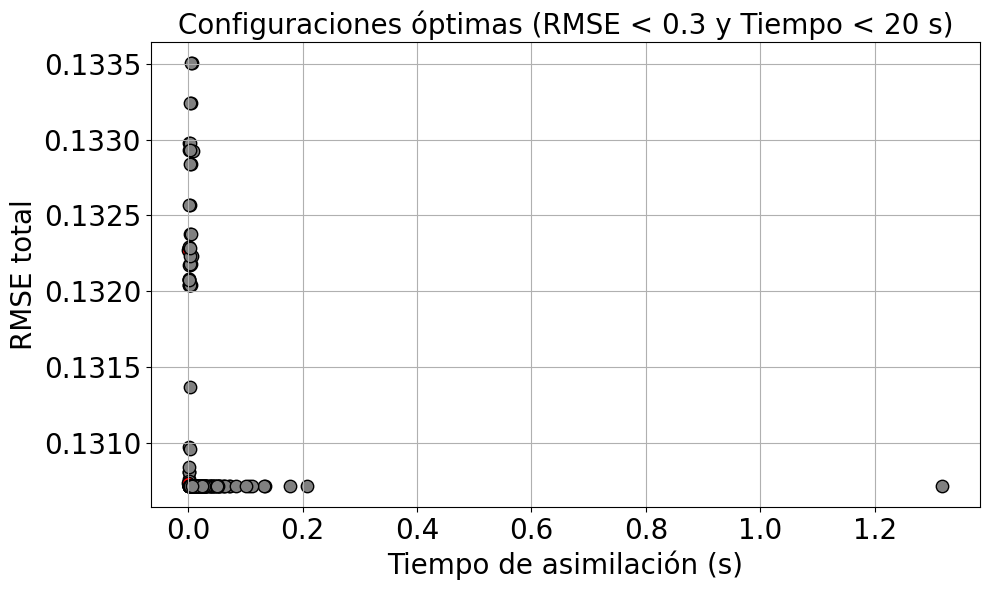

In [5]:
# Cargar los resultados
df = pd.read_csv("analisis_resultados_DA.csv")

# Filtro por precisión y eficiencia
filtro = (df["rmse_total"] < 0.3) & (df["tiempo"] < 20)
df_filtrado = df[filtro].copy()

# Verificar si hay datos para mostrar
if df_filtrado.empty:
    print("⚠️ No hay configuraciones que cumplan con rmse < 0.3 y tiempo < 20 s.")
else:
    # Calcular el frente de Pareto
    def es_dominado(fila, otros):
        return any(
            (o["rmse_total"] <= fila["rmse_total"] and o["tiempo"] < fila["tiempo"]) or
            (o["rmse_total"] < fila["rmse_total"] and o["tiempo"] <= fila["tiempo"])
            for _, o in otros.iterrows()
        )

    df_filtrado["es_pareto"] = ~df_filtrado.apply(lambda fila: es_dominado(fila, df_filtrado.drop(fila.name)), axis=1)

    # Plot
    plt.figure(figsize=(10, 6))
    for idx, fila in df_filtrado.iterrows():
        color = 'red' if fila["es_pareto"] else 'gray'
        label = f"{fila['metodo']} | {fila['variables']} | sens:{fila['n_sensores']} | f:{fila['frecuencia']}"
        plt.scatter(fila["tiempo"], fila["rmse_total"], c=color, label=label, s=80, edgecolor='black')

    plt.xlabel("Tiempo de asimilación (s)", fontsize=20)
    plt.ylabel("RMSE total", fontsize=20)
    plt.title("Configuraciones óptimas (RMSE < 0.3 y Tiempo < 20 s)", fontsize=20)
    plt.xticks(fontsize=20)
    plt.yticks(fontsize=20)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [64]:
def animate_results(sim_data):
    X_star = sim_data["X_star"]
    Y_star = sim_data["Y_star"]
    u_hist = sim_data["u_history"]
    v_hist = sim_data["v_history"]
    p_hist = sim_data["p_history"]
    T_hist = sim_data["T_history"]
    tau_hist = sim_data["tau_history"]
    resolution = X_star.shape[1]
    adverse_pressure = sim_data["params"].get("presion_adversa", "N/A")

    fig, axs_grid = plt.subplots(2, 2, figsize=(10, 8))
    axs = axs_grid.flatten()

    titles = [
        'Velocity Magnitude |u*|',
        'Temperature T*',
        'Pressure p*',
        'Shear Stress τ*'
    ]
    cmaps = ['jet', 'jet', 'viridis', 'coolwarm']

    # First frame
    datasets = [
        np.sqrt(u_hist[0]**2 + v_hist[0]**2),
        T_hist[0],
        p_hist[0],
        tau_hist[0]
    ]

    for ax, title, cmap, data in zip(axs, titles, cmaps, datasets):
        cf = ax.contourf(X_star, Y_star, data, levels=20, cmap=cmap)
        ax.set_title(title, fontsize=20)
        ax.set_xlabel("x*", fontsize=20)
        ax.set_ylabel("y*", fontsize=20)
        plt.colorbar(cf, ax=ax).ax.tick_params(labelsize=10)

    t_star_0 = 0.0
    fig.suptitle(
        f"Resolution {resolution}x{resolution} | Adverse Pressure = {adverse_pressure} | t* = {t_star_0:.2f}",
        fontsize=20
    )
    plt.tight_layout()

    def update(frame):
        t_star = frame / (len(u_hist) - 1)
        updated_data = [
            np.sqrt(u_hist[frame]**2 + v_hist[frame]**2),
            T_hist[frame],
            p_hist[frame],
            tau_hist[frame]
        ]
        for ax, data, cmap in zip(axs, updated_data, cmaps):
            for coll in list(ax.collections):
                coll.remove()
            ax.contourf(X_star, Y_star, data, levels=20, cmap=cmap)

        fig.suptitle(
            f"Resolution {resolution}x{resolution} | Adverse Pressure = {adverse_pressure} | t* = {t_star:.2f}",
            fontsize=20
        )
        return axs

    anim = FuncAnimation(fig, update, frames=len(u_hist), interval=100, blit=False)
    return anim, fig


In [65]:
# --- Ruta base ---
base_dir = "DA/25x25"

# --- Cargar los más precisos por método ---
# Asegúrate de tener esta tabla ya cargada:
mas_precisos = df.sort_values("rmse_total").groupby("metodo").first().reset_index()

# Crea la carpeta si no existe
output_folder = "anim_DA"
os.makedirs(output_folder, exist_ok=True)

# --- Iterar sobre los más precisos y animar ---
for _, row in mas_precisos.iterrows():
    archivo = row["archivo"]
    ruta = os.path.join(base_dir, archivo)

    print(f"🎞️ Generando animación para: {archivo}")
    with open(ruta, "rb") as f:
        sim_data = pickle.load(f)

    anim, fig = animate_results(sim_data)

    nombre_salida = f"{row['metodo']}_obs{row['n_sensores']}_f{row['frecuencia']}_var{row['variables']}.mp4"
    ruta_salida = os.path.join(output_folder, nombre_salida)

    anim.save(ruta_salida, writer="ffmpeg", dpi=150)
    print(f"✅ Guardado: {ruta_salida}")

    plt.close(fig)

🎞️ Generando animación para: 4dvar_25x25_obs_10_freq_300_var_p.pkl
✅ Guardado: anim_DA/4dvar_obs10_f300_varp.mp4
🎞️ Generando animación para: enkf_25x25_obs_20_freq_70_var_st.pkl
✅ Guardado: anim_DA/enkf_obs20_f70_varst.mp4
🎞️ Generando animación para: kf_25x25_obs_20_freq_300_var_t.pkl
✅ Guardado: anim_DA/kf_obs20_f300_vart.mp4
🎞️ Generando animación para: nudging_25x25_obs_5_freq_70_var_s.pkl
✅ Guardado: anim_DA/nudging_obs5_f70_vars.mp4


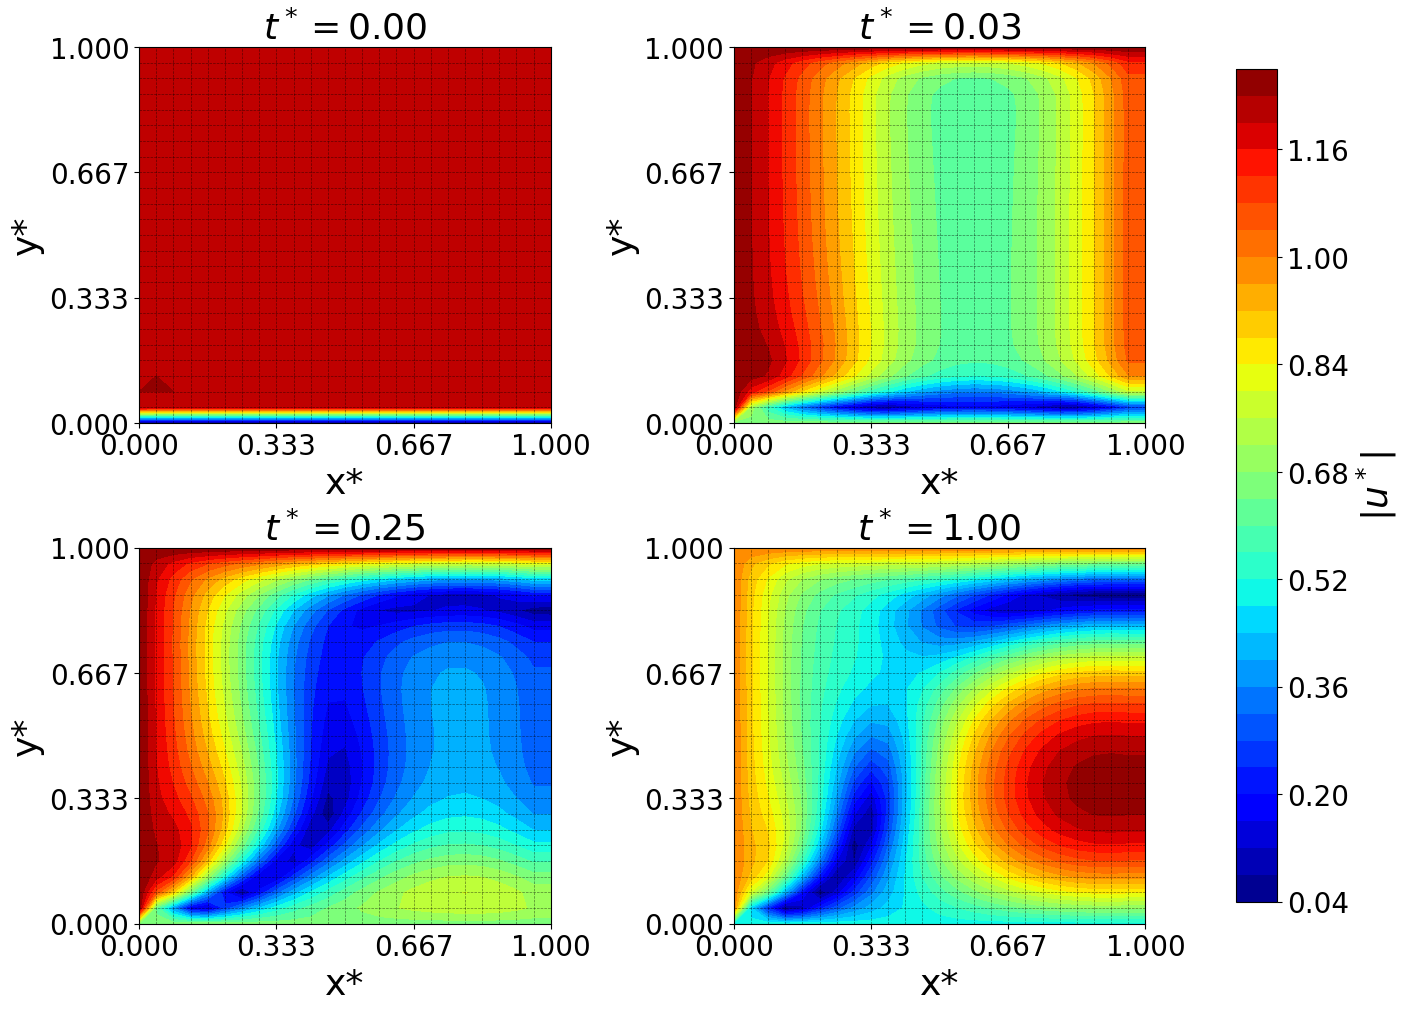

In [20]:
def plot_4_frames_velocidad(path_simulacion, frames=[0, 20, 150, -1], cmap="jet"):
    """
    Representa 4 frames de la magnitud de la velocidad |u*| en un grid 2x2:
    inicio, dos intermedios y final.
    Muestra t* en los títulos y dibuja líneas de malla acorde a la resolución.
    """
    import pickle
    import numpy as np
    import matplotlib.pyplot as plt

    # --- Cargar simulación ---
    with open(path_simulacion, "rb") as f:
        sim = pickle.load(f)

    X_star = sim["X_star"]
    Y_star = sim["Y_star"]
    u_hist = np.array(sim["u_history"])
    v_hist = np.array(sim["v_history"])
    vel_mag = np.sqrt(u_hist**2 + v_hist**2)

    # Reconstruir el tiempo t* (normalizado de 0 a 1)
    n_frames = len(vel_mag)
    time_star = np.linspace(0, 1, n_frames)

    x_vals = X_star[0, :]
    y_vals = Y_star[:, 0]

    # Extraer los frames deseados y preparar los títulos
    selected_frames = [vel_mag[i] if i != -1 else vel_mag[-1] for i in frames]
    frame_indices = [i if i != -1 else n_frames - 1 for i in frames]
    titles = [f"$t^* = {time_star[i]:.2f}$" for i in frame_indices]

    # --- Crear figura en grid 2x2 ---
    fig, axs = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
    axs = axs.flatten()

    for ax, frame_data, title in zip(axs, selected_frames, titles):
        cf = ax.contourf(X_star, Y_star, frame_data, levels=30, cmap=cmap)

        # Dibujar líneas de malla
        for x in x_vals:
            ax.axvline(x, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
        for y in y_vals:
            ax.axhline(y, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

        # Estética
        ax.set_title(title, fontsize=26)
        ax.set_xlabel("x*", fontsize=26)
        ax.set_ylabel("y*", fontsize=26)
        ax.tick_params(axis='both', which='major', labelsize=20)

        # Reducir densidad de ticks
        nx = len(x_vals)
        ny = len(y_vals)
        xticks_idx = np.linspace(0, nx - 1, 4, dtype=int)
        yticks_idx = np.linspace(0, ny - 1, 4, dtype=int)
        ax.set_xticks(x_vals[xticks_idx])
        ax.set_yticks(y_vals[yticks_idx])

    # Colorbar común
    cbar = fig.colorbar(cf, ax=axs, shrink=0.95)
    cbar.set_label(r"$|u^*|$", fontsize=26)
    cbar.ax.tick_params(labelsize=20)

    plt.show()


archivo_sim = "sim_dif_res/25.pkl"
plot_4_frames_velocidad(archivo_sim, frames=[0, 10, 75, -1])


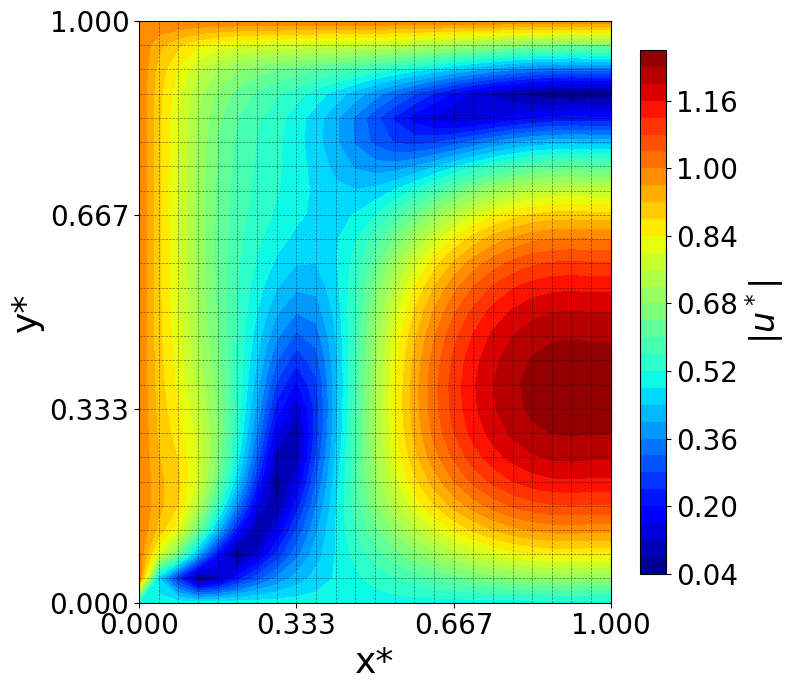

In [8]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

def plot_final_frame_velocidad(path_simulacion, cmap="jet"):
    """
    Representa el último frame de la magnitud de la velocidad |u*|.
    Muestra t* en el título y dibuja líneas de malla.
    """
    # --- Cargar simulación ---
    with open(path_simulacion, "rb") as f:
        sim = pickle.load(f)

    X_star = sim["X_star"]
    Y_star = sim["Y_star"]
    u_hist = np.array(sim["u_history"])
    v_hist = np.array(sim["v_history"])
    vel_mag = np.sqrt(u_hist**2 + v_hist**2)

    # Último frame
    final_frame = vel_mag[-1]
    t_final = 1.0  # Normalizado de 0 a 1

    x_vals = X_star[0, :]
    y_vals = Y_star[:, 0]

    # Crear figura
    fig, ax = plt.subplots(figsize=(8, 7))

    cf = ax.contourf(X_star, Y_star, final_frame, levels=30, cmap=cmap)

    # Dibujar líneas de malla
    for x in x_vals:
        ax.axvline(x, color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    for y in y_vals:
        ax.axhline(y, color='black', linestyle='--', linewidth=0.5, alpha=0.5)

    # Estética
    #ax.set_title(rf"$t^* = {t_final:.2f}$ (Final Frame)", fontsize=26)
    ax.set_xlabel("x*", fontsize=26)
    ax.set_ylabel("y*", fontsize=26)
    ax.tick_params(axis='both', which='major', labelsize=20)

    # Ticks más limpios
    nx = len(x_vals)
    ny = len(y_vals)
    xticks_idx = np.linspace(0, nx - 1, 4, dtype=int)
    yticks_idx = np.linspace(0, ny - 1, 4, dtype=int)
    ax.set_xticks(x_vals[xticks_idx])
    ax.set_yticks(y_vals[yticks_idx])

    # Colorbar
    cbar = fig.colorbar(cf, ax=ax, shrink=0.9)
    cbar.set_label(r"$|u^*|$", fontsize=24)
    cbar.ax.tick_params(labelsize=20)

    plt.tight_layout()
    plt.show()

# Ejemplo de uso
archivo_sim = "DA/25/enkf_25_obs_5_freq_70_var_t.pkl"
plot_final_frame_velocidad(archivo_sim)


In [52]:
import numpy as np
import pickle
from sklearn.metrics import mean_squared_error
import pandas as pd

# --- Funciones ---
def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

def calcular_rmse_variable(sim_data, ref_data, var_name):
    sim = sim_data.get(var_name)
    ref = ref_data.get(var_name)
    if sim is None or ref is None:
        return np.nan
    return np.mean([rmse(s, r) for s, r in zip(sim, ref)])

# --- Cargar simulaciones normalizadas ---
with open("sim_normal/25.pkl", "rb") as f:
    sim_25_norm = pickle.load(f)
with open("sim_normal/25_bloques.pkl", "rb") as f:
    ref_interp = pickle.load(f)

# --- Calcular RMSE por variable ---
rmse_baseline = {
    "archivo": "baseline_sin_DA",
    "metodo": "none",
    "variables": "all",
    "n_sensores": 0,
    "frecuencia": 0,
    "rmse_T": calcular_rmse_variable(sim_25_norm, ref_interp, "T_history"),
    "rmse_p": calcular_rmse_variable(sim_25_norm, ref_interp, "p_history"),
    "rmse_tau": calcular_rmse_variable(sim_25_norm, ref_interp, "tau_history"),
    "tiempo": sim_25_norm.get("asimilacion_time", 0.0)
}

valores = [rmse_baseline[k] for k in ["rmse_T", "rmse_p", "rmse_tau"] if not np.isnan(rmse_baseline[k])]
rmse_baseline["rmse_total"] = np.mean(valores) if valores else np.nan
print("\n📊 RMSE comparación: simulación 25x25 sin DA vs referencia 800x800 downsampled\n")
for k, v in rmse_baseline.items():
    if k.startswith("rmse"):
        print(f"  ▪️ {k}: {v:.5f}")





📊 RMSE comparación: simulación 25x25 sin DA vs referencia 800x800 downsampled

  ▪️ rmse_T: 0.07125
  ▪️ rmse_p: 0.48523
  ▪️ rmse_tau: 0.00572
  ▪️ rmse_total: 0.18740


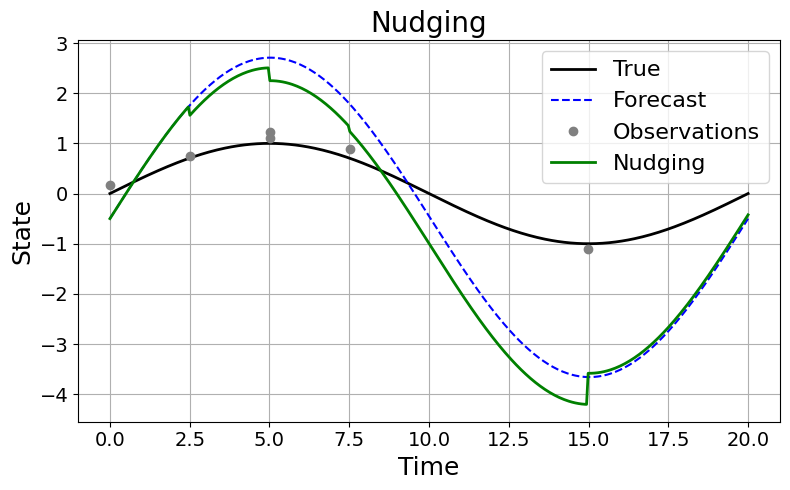

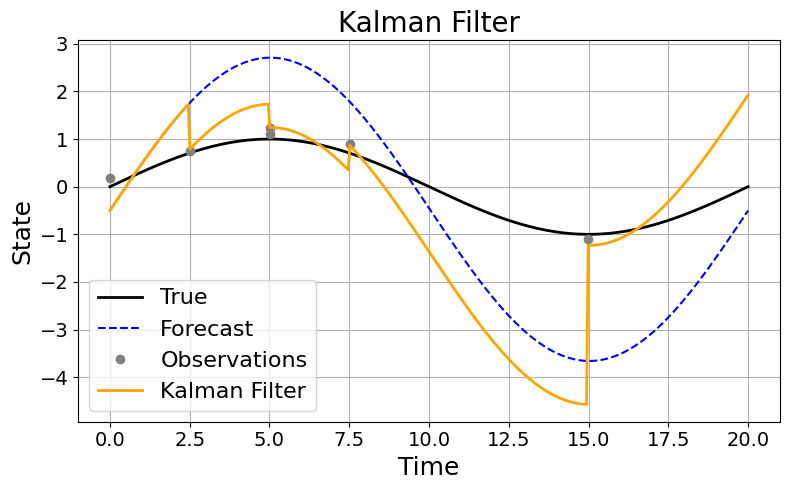

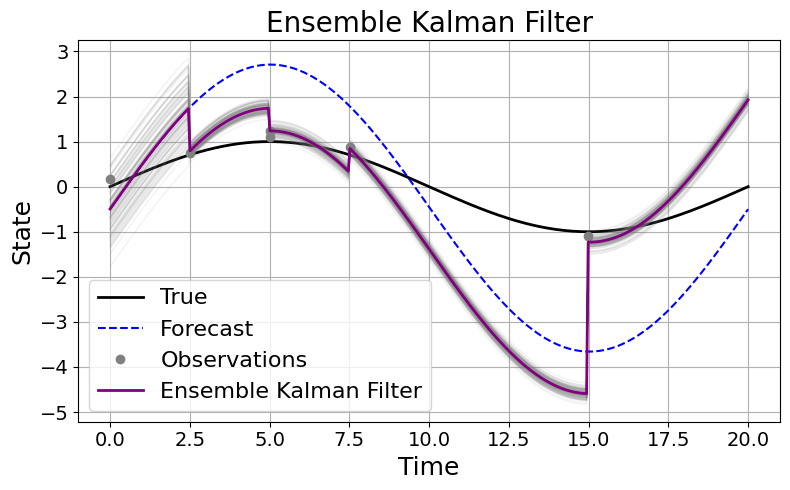

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Semilla para reproducibilidad
np.random.seed(0)

# Tiempo extendido
t = np.linspace(0, 20, 400)
dt = t[1] - t[0]
true_signal = np.sin(np.pi * t / 10)

# Índices de observación hasta t=10 + puntos de curvatura
obs_indices = np.where(t <= 10)[0][::50]
curvature_times = [5, 15]
curvature_indices = [np.argmin(np.abs(t - tc)) for tc in curvature_times]
obs_indices = np.sort(np.concatenate([obs_indices, curvature_indices]))

# Observaciones ruidosas
sigma_obs = 0.1
observations = true_signal[obs_indices] + np.random.normal(0, sigma_obs, size=len(obs_indices))
obs_dict = dict(zip(obs_indices, observations))

# === Parámetros de error ===
R = sigma_obs**2       # Error de observación
B = 0.25               # Covarianza del modelo
H = 1                  # Observación directa

# === Forecast inicial ===
forecast = np.zeros_like(t)
forecast[0] = -0.5

# === Nudging ===
nudging = np.copy(forecast)
nudging_gain = 0.2

# === Kalman Filter ===
kalman = np.copy(forecast)
kalman_gain = B * H / (H * B * H + R)

# === Ensemble Kalman Filter ===
n_ensemble = 100
ensemble = np.zeros((n_ensemble, len(t)))
ensemble[:, 0] = -0.5 + np.random.normal(0, np.sqrt(B), size=n_ensemble)
enkf_gain = B * H / (H * B * H + R)
enkf_mean = np.zeros_like(t)
enkf_mean[0] = ensemble[:, 0].mean()

# === Simulación ===
for i in range(1, len(t)):
    model_derivative = np.cos(np.pi * t[i-1] / 10)

    forecast[i] = forecast[i-1] + dt * model_derivative

    # Nudging
    nudging[i] = nudging[i-1] + dt * model_derivative
    if i in obs_indices:
        nudging[i] += nudging_gain * (obs_dict[i] - nudging[i])

    # Kalman
    kalman[i] = kalman[i-1] + dt * model_derivative
    if i in obs_indices:
        kalman[i] += kalman_gain * (obs_dict[i] - kalman[i])

    # EnKF
    for n in range(n_ensemble):
        ensemble[n, i] = ensemble[n, i-1] + dt * model_derivative
        if i in obs_indices:
            perturbed_obs = obs_dict[i] + np.random.normal(0, sigma_obs)
            ensemble[n, i] += enkf_gain * (perturbed_obs - ensemble[n, i])
    enkf_mean[i] = ensemble[:, i].mean()

# === Función para graficar ===
def plot_method(title, method_series, filename, color, show_ensemble=False):
    plt.figure(figsize=(8, 5))
    plt.plot(t, true_signal, label="True", color="black", linewidth=2)
    plt.plot(t, forecast, linestyle="--", label="Forecast", color="blue")
    plt.plot(t[obs_indices], observations, 'o', label="Observations", color="gray", markersize=6)

    if show_ensemble:
        for n in range(n_ensemble):
            plt.plot(t, ensemble[n], color="gray", alpha=0.1, linewidth=1)

    plt.plot(t, method_series, label=title, linewidth=2, color=color)
    plt.title(title, fontsize=20)
    plt.xlabel("Time", fontsize=18)
    plt.ylabel("State", fontsize=18)
    plt.grid(True)
    plt.legend(fontsize=16)
    plt.tick_params(axis='both', labelsize=14)
    plt.tight_layout()
    plt.savefig(f"{filename}.png", dpi=300)
    plt.show()

# === Graficar por separado usando colores originales ===
plot_method("Nudging", nudging, "nudging", color="green")
plot_method("Kalman Filter", kalman, "kalman_filter", color="orange")
plot_method("Ensemble Kalman Filter", enkf_mean, "enkf", color="purple", show_ensemble=True)


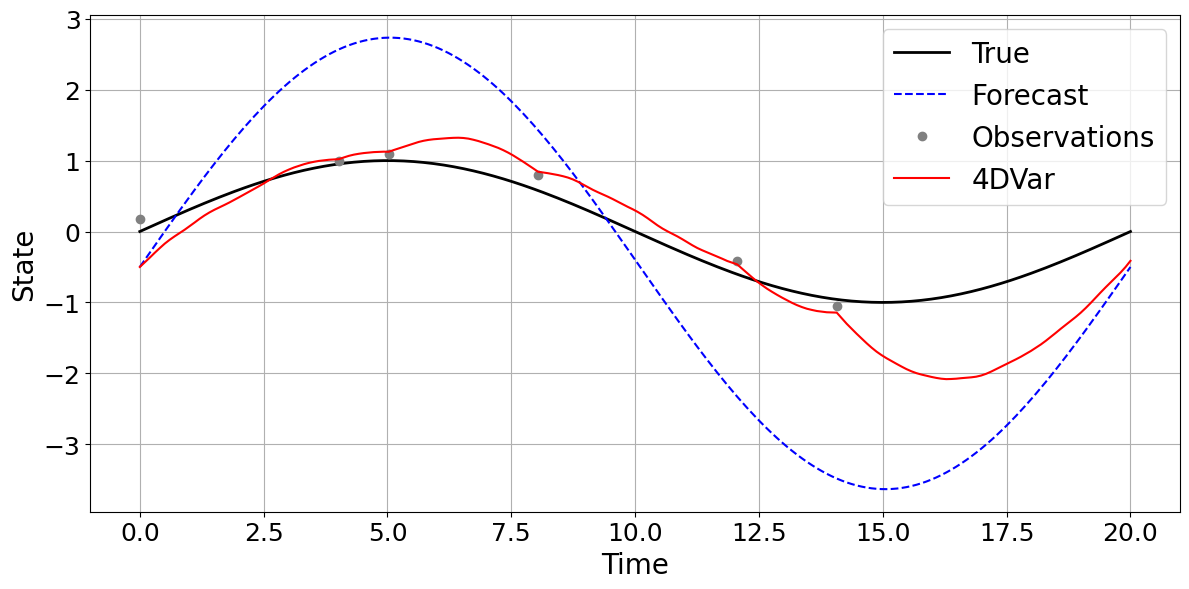

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# --- Parámetros de la simulación ---
np.random.seed(0)
t = np.linspace(0, 20, 200)
dt = t[1] - t[0]
true_signal = np.sin(np.pi * t / 10)

# Observaciones
obs_indices = np.arange(0, 150, 40)
obs_indices = np.append(obs_indices, [50, 140])
obs_indices = np.unique(obs_indices)
sigma_obs = 0.1
observations = true_signal[obs_indices] + np.random.normal(0, sigma_obs, len(obs_indices))
obs_dict = dict(zip(obs_indices, observations))

# Forecast
forecast = np.zeros_like(t)
forecast[0] = -0.5
for i in range(1, len(t)):
    forecast[i] = forecast[i-1] + dt * np.cos(np.pi * t[i-1] / 10)

# Modelo
def model_rhs(x):
    return np.cos(np.pi * x / 10)

def cost_fn_continuous(x_var, x0_fixed, t_start_idx, obs_local):
    x_full = np.concatenate(([x0_fixed], x_var))
    cost = 0.0
    for i in range(1, len(x_full)):
        model_pred = x_full[i-1] + dt * model_rhs(t[t_start_idx + i - 1])
        cost += (x_full[i] - model_pred)**2 / 0.01  # modelo
    for rel_idx, obs_val in obs_local.items():
        cost += (x_full[rel_idx] - obs_val)**2 / sigma_obs**2  # observaciones
    return cost

# === Parámetro ajustable: número de ventanas ===
n_windows = 1  # <-- puedes cambiar este valor
steps_total = len(t)
window_size = steps_total // n_windows

# 4DVar por ventanas con continuidad
x_4dvar = np.zeros_like(t)
x_4dvar[0] = forecast[0]

for w in range(n_windows):
    start = w * window_size
    end = (w + 1) * window_size if w < n_windows - 1 else steps_total
    steps = end - start

    x0_fixed = x_4dvar[start]  # valor inicial de la ventana
    x_init = forecast[start + 1:end]  # valores a optimizar

    obs_local = {i - start: obs_dict[i] for i in obs_indices if start <= i < end}

    result = minimize(cost_fn_continuous, x_init, args=(x0_fixed, start, obs_local), method='L-BFGS-B')
    x_4dvar[start + 1:end] = result.x

# --- Plot ---
plt.figure(figsize=(12, 6))
plt.plot(t, true_signal, label="True", color="black", linewidth=2)
plt.plot(t, forecast, label="Forecast", linestyle="--", color="blue")
plt.plot(t[obs_indices], observations, 'o', label="Observations", color="gray", markersize=6)
plt.plot(t, x_4dvar, label=f"4DVar", color="red")
#plt.title("4DVar Trajectory ", fontsize=20)
plt.xlabel("Time", fontsize=20)
plt.ylabel("State", fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.legend(fontsize=20)
plt.tight_layout()
plt.show()


In [91]:
Lx_star = Ly_star = 1.0
dx_star = Lx_star / (25 - 1)
dy_star = Ly_star / (25 - 1)
dt_cfl = 0.008 * dx_star / 1.0
nt = int(np.ceil(2.0 / dt_cfl))
f1 = nt/300
f2 = nt/150
f3 = nt/75

In [94]:
print(f1, f2, f3)
print(nt)

20.0 40.0 80.0
6000


In [96]:
import pandas as pd

# 1. Cargar archivos
df_precise = pd.read_csv("mejores_precisos.csv")
df_efficient = pd.read_csv("mejores_eficientes.csv")
df_balanced = pd.read_csv("mejores_equilibrados.csv")

# 2. Añadir columna 'group' y combinar
df_precise["group"] = "Accuracy"
df_efficient["group"] = "Efficiency"
df_balanced["group"] = "Balance"

df = pd.concat([df_precise, df_efficient, df_balanced], ignore_index=True)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# 3. Calcular observaciones
df["observations"] = df["n_sensores"] * df["frecuencia"]

# 4. Escalar observaciones dividiendo por 6000
df["observations_norm"] = df["observations"] / 6000

# 5. Ajustar tiempo de 4DVar (÷ 1e5) y renombrar método
df["metodo"] = df["metodo"].apply(
    lambda x: "4dvar (×1e-3)" if x.lower() == "4dvar" else x
)
df["tiempo"] = df.apply(
    lambda row: row["tiempo"] * 1e-3 if "4dvar" in row["metodo"].lower() else row["tiempo"],
    axis=1
)

# 6. Calcular RMSE relativo al mínimo
min_rmse = df["rmse_total"].min()
df["rmse_relative"] = df["rmse_total"] / min_rmse

# 7. Mostrar configuración óptima
best_config = df[df["rmse_total"] == min_rmse]
print("\n🔍 Best Configuration (Min RMSE):\n")
print(best_config.to_string(index=False))

# 8. Mostrar tabla completa procesada
print("\n📊 Full Processed Data:\n")
print(df[["metodo", "variables", "observations", "observations_norm", "rmse_total", "rmse_relative", "tiempo", "group"]].to_string(index=False))



🔍 Best Configuration (Min RMSE):

metodo                            archivo  n_sensores  frecuencia variables   rmse_t   rmse_p  rmse_tau  rmse_total   tiempo  n_variables    group  score_balance  observations  observations_norm  rmse_relative
    kf kf_25x25_obs_20_freq_300_var_t.pkl          20         300         t 0.088035 0.040379  0.263728    0.130714 0.053965            1 Accuracy            NaN          6000                1.0            1.0

📊 Full Processed Data:

       metodo variables  observations  observations_norm  rmse_total  rmse_relative   tiempo      group
4dvar (×1e-3)         p          3000           0.500000    0.131704       1.007577 0.027120   Accuracy
         enkf        st          1400           0.233333    0.130715       1.000007 0.022381   Accuracy
           kf         t          6000           1.000000    0.130714       1.000000 0.053965   Accuracy
      nudging         s           350           0.058333    0.130715       1.000007 0.000760   Accuracy


In [101]:
import pandas as pd

# 1. Cargar los archivos CSV
df_precise = pd.read_csv("mejores_precisos.csv")
df_efficient = pd.read_csv("mejores_eficientes.csv")
df_balanced = pd.read_csv("mejores_equilibrados.csv")

# 2. Añadir columna de grupo y unir
df_precise["group"] = "Accuracy"
df_efficient["group"] = "Efficiency"
df_balanced["group"] = "Balance"
df = pd.concat([df_precise, df_efficient, df_balanced], ignore_index=True)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# 3. Calcular número total de observaciones
df["observations"] = df["n_sensores"] * df["frecuencia"]

# 4. Ajustar tiempo si el método es 4dvar (÷1e3) y anotar
df["metodo"] = df["metodo"].apply(lambda x: "4dvar (×1e-3)" if x.lower() == "4dvar" else x)
df["tiempo"] = df.apply(
    lambda row: row["tiempo"] * 1e-3 if "4dvar" in row["metodo"].lower() else row["tiempo"],
    axis=1
)

# 5. Identificar la mejor configuración (mínimo RMSE total)
best_row = df[df["rmse_total"] == df["rmse_total"].min()].iloc[0]
rmse_ref = best_row["rmse_total"]
tiempo_ref = best_row["tiempo"]

# 6. Calcular métricas relativas respecto al mejor
df["rmse_relative"] = df["rmse_total"] / rmse_ref
df["tiempo_relative"] = df["tiempo"] / tiempo_ref

# 7. Mostrar configuración óptima
print("\n🔍 Best RMSE Configuration:\n")
print(best_row.to_string())

# 8. Mostrar tabla comparativa con métricas relativas
print("\n📊 Comparison Table (Relative to Best RMSE Configuration):\n")

# Mostrar todas las filas y columnas completas
pd.set_option('display.max_rows', None)         # Sin límite de filas
pd.set_option('display.max_columns', None)      # Sin límite de columnas
pd.set_option('display.width', None)            # Ancho de impresión ilimitado
pd.set_option('display.max_colwidth', None)     # Ancho de columnas sin truncamiento

# Mostrar todos los datos
print(df.to_string(index=False))




🔍 Best RMSE Configuration:

metodo                                           kf
archivo          kf_25x25_obs_20_freq_300_var_t.pkl
n_sensores                                       20
frecuencia                                      300
variables                                         t
rmse_t                                     0.088035
rmse_p                                     0.040379
rmse_tau                                   0.263728
rmse_total                                 0.130714
tiempo                                     0.053965
n_variables                                       1
group                                      Accuracy
score_balance                                   NaN
observations                                   6000

📊 Comparison Table (Relative to Best RMSE Configuration):

       metodo                               archivo  n_sensores  frecuencia variables   rmse_t   rmse_p  rmse_tau  rmse_total   tiempo  n_variables      group  score_balance  observat

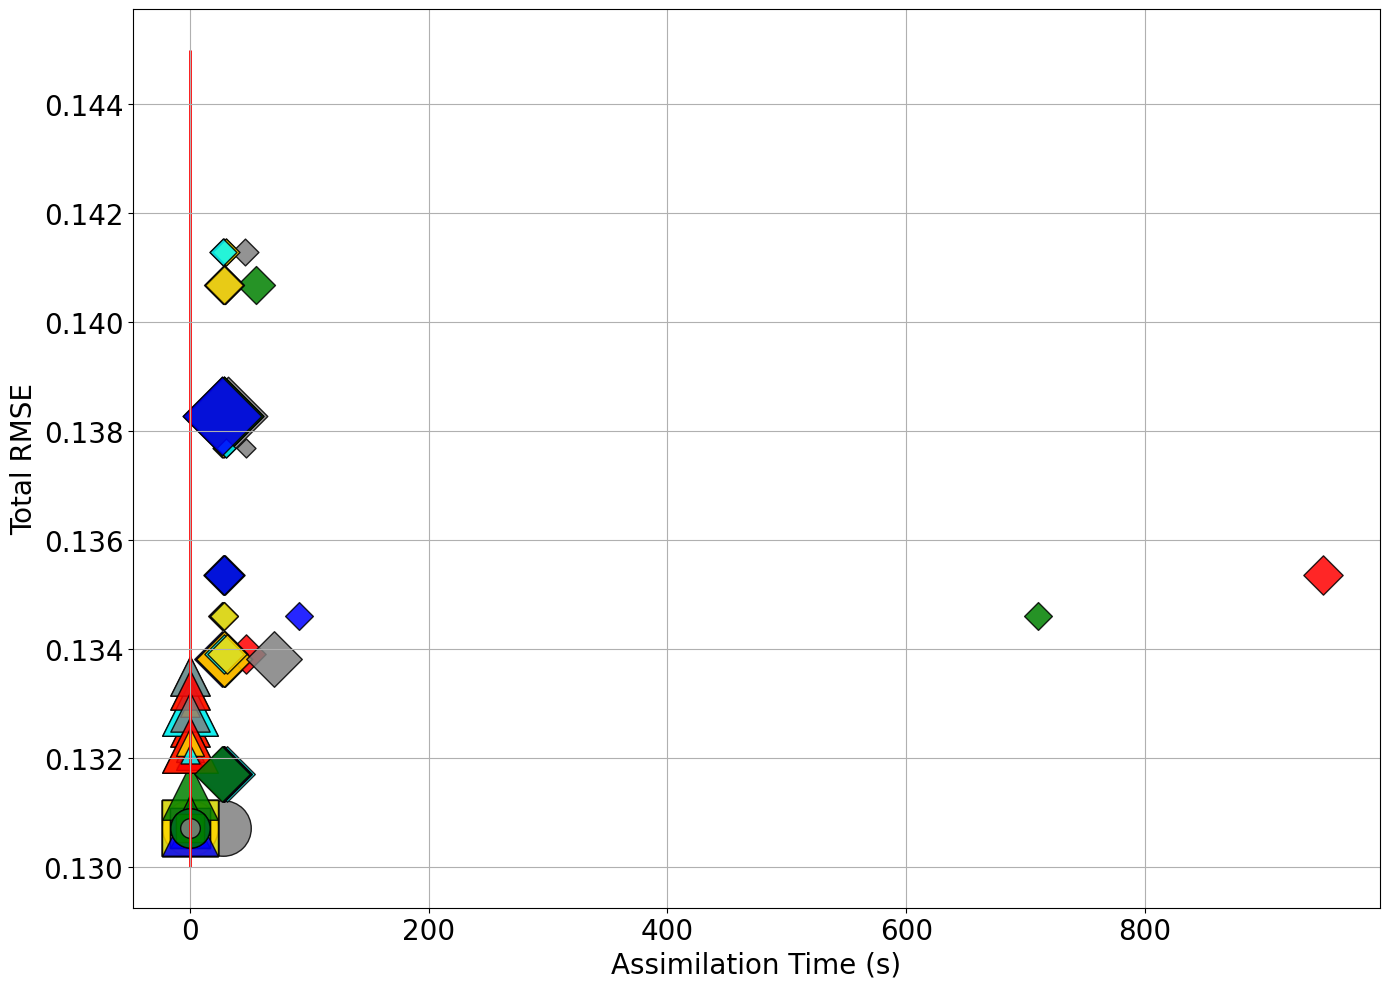

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as patches

# === 1. Cargar resultados globales ===
df = pd.read_csv("analisis_resultados_DA.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df["observations"] = df["n_sensores"] * df["frecuencia"]
df["observations_norm"] = df["observations"] / 6000

# === 2. Mapas de estilo ===
color_map = {
    "t": "red", "p": "green", "s": "blue", "st": "gold", "tp": "darkorange", "ts": "violet", "pst": "cyan"
}
marker_map = {
    "kf": "o", "enkf": "s", "4dvar": "D", "nudging": "^"
}

# === 3. Figura principal ===
plt.figure(figsize=(14, 10))

for _, row in df.iterrows():
    color = color_map.get(row["variables"], "gray")
    marker = marker_map.get(row["metodo"], "o")
    size = row["observations_norm"] * 1600
    plt.scatter(
        row["tiempo"],
        row["rmse_total"],
        color=color,
        s=size,
        marker=marker,
        edgecolor="black",
        alpha=0.85
    )

# === 4. Leyenda ===
legend_elements = []

# Formas: Método
for method, marker in marker_map.items():
    legend_elements.append(
        Line2D([0], [0], marker=marker, label=f"Method: {method}",
               color='w', markerfacecolor='gray', markeredgecolor='black', markersize=14)
    )

# Colores: Variables
for var, color in color_map.items():
    legend_elements.append(
        Line2D([0], [0], marker='o', label=f"Parameter: {var}",
               color='w', markerfacecolor=color, markeredgecolor='black', markersize=14)
    )

# Tamaños: Observaciones
for obs in [1000, 3000, 6000]:
    legend_elements.append(
        plt.scatter([], [], s=(obs / 6000) * 1600, color='gray', edgecolor='black',
                    label=f"Observations: {obs}")
    )


plt.legend(
    handles=legend_elements,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    title="Legend",
    fontsize=20,
    title_fontsize=22,
    labelspacing=1.5,
    borderpad=1.5,
    ncol=2  # ✅ Mostrar en dos columnas
)


# === 5. Zoom region ===
zoom_box = dict(x=0.0, y=0.13, width=0.03, height=0.015)
rect = patches.Rectangle(
    (zoom_box["x"], zoom_box["y"]),
    zoom_box["width"],
    zoom_box["height"],
    linewidth=2,
    edgecolor='red',
    facecolor='none',
    linestyle='-'
)
plt.gca().add_patch(rect)
#plt.text(zoom_box["x"] + zoom_box["width"] + 0.001, zoom_box["y"] + 0.001, "Zoom in ↓", fontsize=16)

# === 6. Etiquetas ===
#plt.title("All Configurations (Color: Parameter | Shape: Method | Size: #Obs.)", fontsize=22)
plt.xlabel("Assimilation Time (s)", fontsize=20)
plt.ylabel("Total RMSE", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.grid(True)
plt.tight_layout()
plt.show()


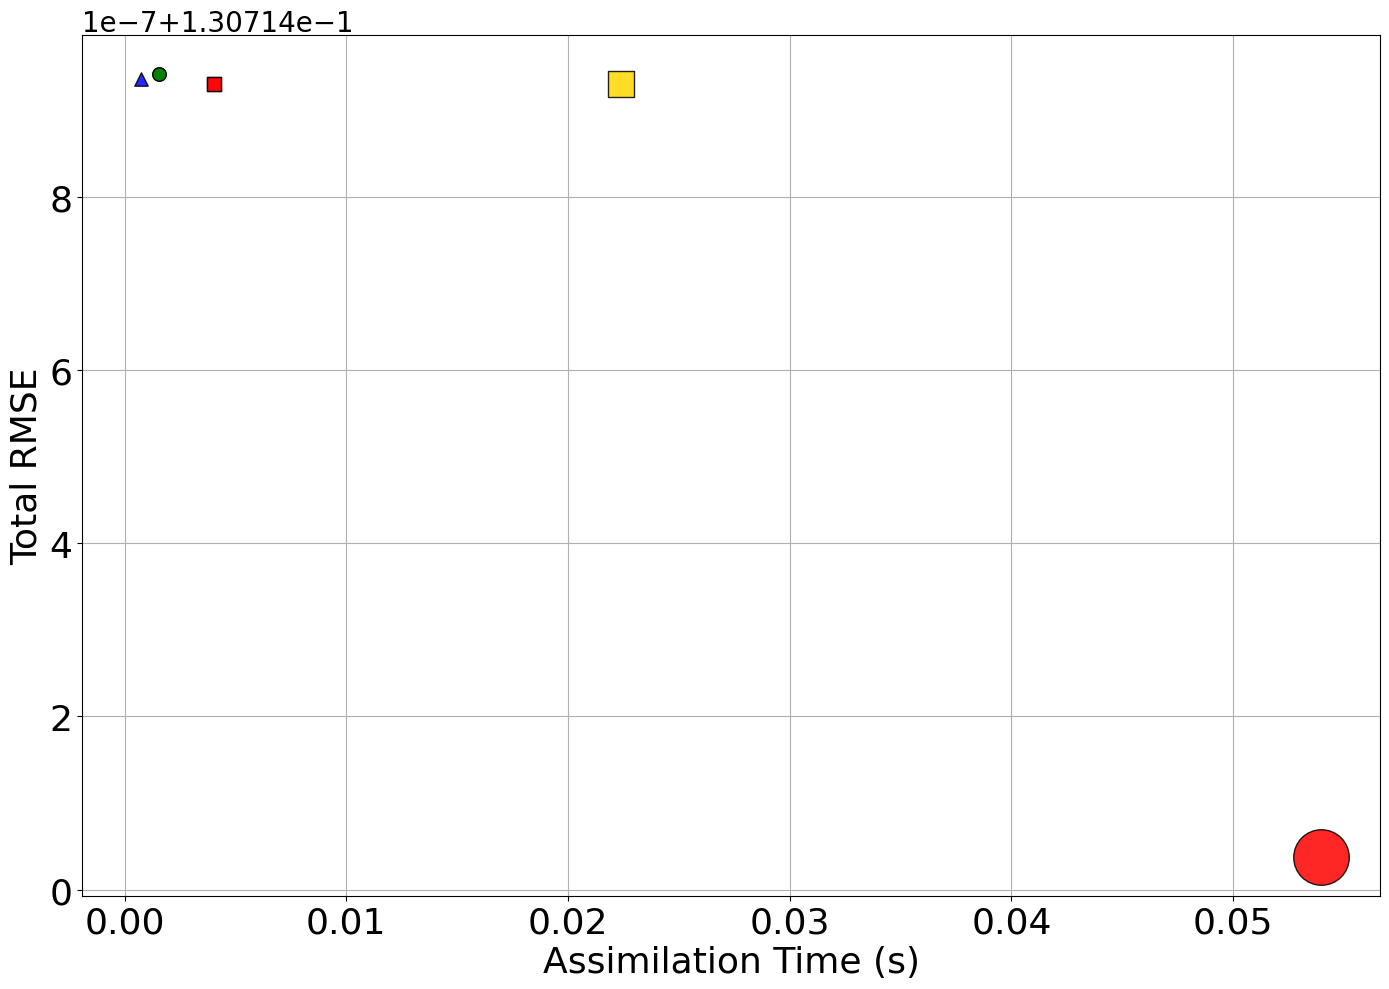

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# === 1. Cargar datos ===
df_precisos = pd.read_csv("mejores_precisos.csv")
df_eficientes = pd.read_csv("mejores_eficientes.csv")
df_equilibrados = pd.read_csv("mejores_equilibrados.csv")

df_precisos["grupo"] = "Accuracy"
df_eficientes["grupo"] = "Efficiency"
df_equilibrados["grupo"] = "Balance"

df = pd.concat([df_precisos, df_eficientes, df_equilibrados], ignore_index=True)
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df["observations"] = df["n_sensores"] * df["frecuencia"]
df["observations_norm"] = df["observations"] / 6000

# === 2. Filtrar por RMSE redondeado ===
df = df[df["rmse_total"].round(4) == 0.1307]

# === 3. Mapas de estética ===
color_map = {
    "t": "red", "p": "green", "s": "blue", "st": "gold"
}
marker_map = {
    "kf": "o", "enkf": "s", "4dvar": "D", "nudging": "^"
}

# === 4. Plot ===
plt.figure(figsize=(14, 10))

for _, row in df.iterrows():
    color = color_map.get(row["variables"], "gray")
    marker = marker_map.get(row["metodo"], "o")
    size = row["observations_norm"] * 1600  # Tamaños más grandes para visibilidad
    plt.scatter(
        row["tiempo"],
        row["rmse_total"],
        color=color,
        s=size,
        marker=marker,
        edgecolor="black",
        alpha=0.85
    )

# === 5. Leyenda combinada ===
legend_elements = []

# Formas: Método
for method, marker in marker_map.items():
    legend_elements.append(
        Line2D([0], [0], marker=marker, label=f"Method: {method}",
               color='w', markerfacecolor='gray', markeredgecolor='black', markersize=14)
    )

# Colores: Parámetros
for var, color in color_map.items():
    legend_elements.append(
        Line2D([0], [0], marker='o', label=f"Parameter: {var}",
               color='w', markerfacecolor=color, markeredgecolor='black', markersize=14)
    )

# Tamaños: Observaciones
for obs in [1000, 3000, 6000]:
    legend_elements.append(
        plt.scatter([], [], s=(obs / 6000) * 1600, color='gray', edgecolor='black',
                    label=f"Observations: {obs}")
    )

# Aumentar tamaño de la notación científica del eje y
ax = plt.gca()  # Obtener el eje actual
y_offset_text = ax.yaxis.get_offset_text()
y_offset_text.set_size(20)  # Cambiar tamaño de fuente a 20 (ajusta si quieres)



# === 6. Etiquetas y formato ===
#plt.title("Configurations with Total RMSE ≈ 0.1307", fontsize=26)
plt.xlabel("Assimilation Time (s)", fontsize=26)
plt.ylabel("Total RMSE", fontsize=26)
plt.xticks(fontsize=26)
plt.yticks(fontsize=26)
plt.grid(True)
plt.tight_layout()
plt.show()
